## **Topic:** Predicting Hospital Readmission for Diabetic Patients
---
### **Course:** CMPS 262 Capstone Project  
### **Domain:** Healthcare and Medical Data
---
**Group Members:** Hala Daher and Rawan Ahmad

**Instructor:** Professor Maher Abdallah

**Semester:** Spring 2026



# ***Milestone 1: Project Proposal***


---



## **1. Project Domain and Subtopic:**


- This project belongs to the **healthcare and medical data domain** (predictive healthcare analytics).

- The subtopic of the project is **hospital readmission prediction**. The task is to use the clinical and hospital visit information of diabetic patients to predict whether a patient will return to the hospital after discharge.

##**2. Problem Statement and Objectives:**



Hospital readmission among diabetic patients refers to a patient returning to the hospital after being discharged from a previous hospitalization. It is a major healthcare concern because:

- indicates possible complications or poor disease management
- increases hospital costs
- negatively affects patient health outcomes
- reflects the quality of care and discharge planning

For these reasons, hospitals and healthcare organizations aim to identify patients who are at high risk of readmission. Being able to predict which diabetic patients are at high risk of readmission allows healthcare providers to:
- Design personalized treatment plans
- Improve post discharge follow up
- Reduce avoidable hospital readmissions.

Predictive analytics and machine learning techniques can help address this problem by learning patterns from historical patient records. By analyzing demographic information, hospital visit history, and treatment details, it is possible to estimate the probability that a patient will return to the hospital after discharge.



###**- Objectives:**



1. To explore and understand the characteristics of hospital encounter data using exploratory data analysis.

2. To identify diabetic patient features and clinical variables associated with hospital readmission.

3. To preprocess the dataset by handling missing values, transforming categorical variables, and preparing the data for machine learning.

4. To implement classification models capable of predicting readmission risk.

5. To evaluate model performance using appropriate metrics such as accuracy, precision, recall, and Fβ-score.

6. To interpret the model results and discuss the medical and practical implications of the findings.

## **3. Dataset Source and Description:**



###**- Dataset Source:**



The dataset used in this project is the “Diabetes 130-US Hospitals for Years 1999-2008” dataset obtained from the UCI Machine Learning Repository. The dataset contains hospital encounter records collected from 130 hospitals in the United States over a 10-year period (1999-2008).

link: https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008



###**- Dataset Structure:**



The dataset consists of two related tables:
- The first table is  mapping table used to replace numerical codes with meaningful categorical labels. (67 x 2)
- The second table contains patient level hospital encounter records for diabetic patients. (101766 x 50)



###**- Data Quality Observations:**


The data is raw and unprocessed:
- "?" is used instead of proper missing values.
- Many categorical variables stored as text.
- ID-based features require mapping.
- Lab results are highly incomplete.
- No preprocessing, encoding, or cleaning applied.


###**- Dataset Variables:**




- The first table contains numerical codes and its corresponding description.

- Each row in the second table represents a single encounter and includes demographic information (race, gender, age, weight), admission and discharge details (admission_type_id, discharge_disposition_id, admission_source_id, time_in_hospital, payer_code, medical_specialty), hospital utilization history (number_outpatient, number_emergency, number_inpatient), clinical variables (num_lab_procedures, num_procedures, num_medications, number_diagnoses, diag_1, diag_2, diag_3), laboratory test results (max_glu_serum, A1Cresult), and diabetes medication information (such as metformin, insulin, and others), as well as treatment change indicators (change, diabetesMed).

- The variables encounter_id and patient_nbr are unique identifiers.



###**- Target variable:**



readmitted -> indicates whether the diabetic patient was readmitted within 30 days or more.



###**- Dataset Visualization:**

In [1]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")
print("Sample:")
display(df.head())

Sample:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
print(f"Size:{df.shape}")

Size:(101766, 50)


In [3]:
print("Columns and datatypes:")
display(df.dtypes)

Columns and datatypes:


,0
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64


In [4]:
ids_mapping = pd.read_csv("IDS_mapping.csv")
print("Sample:")
display(ids_mapping.head())

Sample:


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


In [5]:
print(f"Size:{ids_mapping.shape}")

Size:(67, 2)


In [6]:
print("Columns and datatypes:")
display(ids_mapping.dtypes)

Columns and datatypes:


,0
admission_type_id,object
description,object


##**4. Planned Analytical Approach:**





### **- Data Preparation and cleaning:**









- Remove irrelevant identifiers
- Handling missing values
- Address feature datatypes
- Scale numerical variables

### **- Exploratory Data Analysis (EDA):**


- Summary statistics and distribution
- Visualization of relationships between variables and readmission
- Detect patterns and anomalies with visualization

### **- Feature Engineering and Selection:**


- Create meaningful derived features
- Select most relevant ones for readmission


### **- Machine Learning Models:**


Since the target variable is binary, so supervised classification algorithms will be applied:
- Baseline: most frequent class
- Random Forest
- Gradient Boosting
- SVM

Comparing multiple models will allow identification of the most suitable method for predicting hospital readmission.

### **- Model Evaluation:**


Model performance will be evaluated using:
- Fβ score
- Confusion matrix
- AUC
- Other metrics could be: accuracy, precision, recall
(including their confidence intervals)

The results will be interpreted to determine which patient factors contribute most to hospital readmission risk.

#***Milestone 2: Data Preparation & EDA***


---



## **1. Data Loading & Schema Checks**

### **Imports & setup:**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, fbeta_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay
from sklearn.inspection import permutation_importance

In [8]:
# reproducibility
np.random.seed(42)

# display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

### **Loading datasets:**

In [9]:
# load the main dataset
display(df.head())

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [10]:
# load IDS mapping (admission type, discharge disposition, admission source)
display(ids_mapping.head())

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


 ### **Data Types & Schema:**

In [11]:
# changing the names
print(df.columns)
df.columns = df.columns.str.lower().str.strip()
df.columns = df.columns.str.replace("-", "_")
df.columns = df.columns.str.replace(" ", "_")
print(df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')
Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weigh

In [12]:
# datasets shape
print(f"Main dataset shape: {df.shape}")
print(f"IDS mapping shape: {ids_mapping.shape}")

Main dataset shape: (101766, 50)
IDS mapping shape: (67, 2)


In [13]:
# number of rows
print(f"Total rows: {len(df)}")

Total rows: 101766


In [14]:
# uniqueness
print(f"Unique encounter_id: {df['encounter_id'].nunique()}")

Unique encounter_id: 101766


In [15]:
# note: this identifies a person, not a visit.
# the same patient can be admitted multiple times, so this number will be lower than the row count
print(f"Unique patient_nbr: {df['patient_nbr'].nunique()}")

dups = df.duplicated(subset='encounter_id').sum()
print(f"Duplicate encounters: {dups}")

Unique patient_nbr: 71518
Duplicate encounters: 0


In [16]:
# data dictionary

# replacing '?' with NaN: the dataset uses '?' as its missing value token instead of a standard blank or NaN.
# so we replace all occurrences globally before any analysis so that pandas treats them correctly.
df.replace('?', np.nan, inplace=True)

dictionary = {
    "Column" : df.columns,
    "Datatypes" : df.dtypes.values,
    "Non-NaN Count" : df.notnull().sum().values,
    "NaN Count" : df.isnull().sum().values,
    "Missing (%)" : (df.isnull().mean() * 100).round(1).values,
    "Sample" : [str(df[col].dropna().unique()[:3].tolist()) for col in df.columns]
}

table = pd.DataFrame(dictionary).to_markdown(index=False)
display(Markdown(table))

| Column                   | Datatypes   |   Non-NaN Count |   NaN Count |   Missing (%) | Sample                                                                     |
|:-------------------------|:------------|----------------:|------------:|--------------:|:---------------------------------------------------------------------------|
| encounter_id             | int64       |          101766 |           0 |           0   | [2278392, 149190, 64410]                                                   |
| patient_nbr              | int64       |          101766 |           0 |           0   | [8222157, 55629189, 86047875]                                              |
| race                     | object      |           99493 |        2273 |           2.2 | ['Caucasian', 'AfricanAmerican', 'Other']                                  |
| gender                   | object      |          101766 |           0 |           0   | ['Female', 'Male', 'Unknown/Invalid']                                      |
| age                      | object      |          101766 |           0 |           0   | ['[0-10)', '[10-20)', '[20-30)']                                           |
| weight                   | object      |            3197 |       98569 |          96.9 | ['[75-100)', '[50-75)', '[0-25)']                                          |
| admission_type_id        | int64       |          101766 |           0 |           0   | [6, 1, 2]                                                                  |
| discharge_disposition_id | int64       |          101766 |           0 |           0   | [25, 1, 3]                                                                 |
| admission_source_id      | int64       |          101766 |           0 |           0   | [1, 7, 2]                                                                  |
| time_in_hospital         | int64       |          101766 |           0 |           0   | [1, 3, 2]                                                                  |
| payer_code               | object      |           61510 |       40256 |          39.6 | ['MC', 'MD', 'HM']                                                         |
| medical_specialty        | object      |           51817 |       49949 |          49.1 | ['Pediatrics-Endocrinology', 'InternalMedicine', 'Family/GeneralPractice'] |
| num_lab_procedures       | int64       |          101766 |           0 |           0   | [41, 59, 11]                                                               |
| num_procedures           | int64       |          101766 |           0 |           0   | [0, 5, 1]                                                                  |
| num_medications          | int64       |          101766 |           0 |           0   | [1, 18, 13]                                                                |
| number_outpatient        | int64       |          101766 |           0 |           0   | [0, 2, 1]                                                                  |
| number_emergency         | int64       |          101766 |           0 |           0   | [0, 1, 2]                                                                  |
| number_inpatient         | int64       |          101766 |           0 |           0   | [0, 1, 2]                                                                  |
| diag_1                   | object      |          101745 |          21 |           0   | ['250.83', '276', '648']                                                   |
| diag_2                   | object      |          101408 |         358 |           0.4 | ['250.01', '250', '250.43']                                                |
| diag_3                   | object      |          100343 |        1423 |           1.4 | ['255', 'V27', '403']                                                      |
| number_diagnoses         | int64       |          101766 |           0 |           0   | [1, 9, 6]                                                                  |
| max_glu_serum            | object      |            5346 |       96420 |          94.7 | ['>300', 'Norm', '>200']                                                   |
| a1cresult                | object      |           17018 |       84748 |          83.3 | ['>7', '>8', 'Norm']                                                       |
| metformin                | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Up']                                                     |
| repaglinide              | object      |          101766 |           0 |           0   | ['No', 'Up', 'Steady']                                                     |
| nateglinide              | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Down']                                                   |
| chlorpropamide           | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Down']                                                   |
| glimepiride              | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Down']                                                   |
| acetohexamide            | object      |          101766 |           0 |           0   | ['No', 'Steady']                                                           |
| glipizide                | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Up']                                                     |
| glyburide                | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Up']                                                     |
| tolbutamide              | object      |          101766 |           0 |           0   | ['No', 'Steady']                                                           |
| pioglitazone             | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Up']                                                     |
| rosiglitazone            | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Up']                                                     |
| acarbose                 | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Up']                                                     |
| miglitol                 | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Down']                                                   |
| troglitazone             | object      |          101766 |           0 |           0   | ['No', 'Steady']                                                           |
| tolazamide               | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Up']                                                     |
| examide                  | object      |          101766 |           0 |           0   | ['No']                                                                     |
| citoglipton              | object      |          101766 |           0 |           0   | ['No']                                                                     |
| insulin                  | object      |          101766 |           0 |           0   | ['No', 'Up', 'Steady']                                                     |
| glyburide_metformin      | object      |          101766 |           0 |           0   | ['No', 'Steady', 'Down']                                                   |
| glipizide_metformin      | object      |          101766 |           0 |           0   | ['No', 'Steady']                                                           |
| glimepiride_pioglitazone | object      |          101766 |           0 |           0   | ['No', 'Steady']                                                           |
| metformin_rosiglitazone  | object      |          101766 |           0 |           0   | ['No', 'Steady']                                                           |
| metformin_pioglitazone   | object      |          101766 |           0 |           0   | ['No', 'Steady']                                                           |
| change                   | object      |          101766 |           0 |           0   | ['No', 'Ch']                                                               |
| diabetesmed              | object      |          101766 |           0 |           0   | ['No', 'Yes']                                                              |
| readmitted               | object      |          101766 |           0 |           0   | ['NO', '>30', '<30']                                                       |

### **Key Observations from Part 1:**

- The dataset contains **101,766 rows and 50 columns**, covering patient demographics, admission details, diagnoses, medications, and the readmission outcome.

- A separate IDS mapping file (67 rows x 2 columns) provides human readable labels for admission_type_id, discharge_disposition_id, and admission_source_id, which will be merged in later steps.

- **encounter_id** is unique per row and no duplicate visits were found.

- Column names were standardized by lowercasing, stripping whitespace, and replacing - and spaces with _ for consistency in python.

- **patient_nbr** has 71,518 unique values vs 101,766 rows confirming that some patients appear multiple times. This will be addressed in Part 3 by keeping only the first encounter per patient to prevent data leakage.

- Missing values were encoded as '?' in the raw file, now replaced globally with NaN.

- Four columns show critically high missingness and will be dropped as high missigness doesn't add information:
  - **weight**: 96.9% missing
  - **max_glu_serum**: 94.7% missing
  - **A1Cresult**: 83.3% missing

- **medical_specialty** and **payer_code** have 49.1% and 39.6% missing respectively, a decision will be made in Part 3.

- Most other columns are complete or have negligible missingness (≤ 2.2%).

- 23 medication columns use categorical values (No/Steady/Up/Down) with zero missing values, indicating complete medication records.

- Here, datatypes are correctly suitable for the data of each column but object type features will be changed to categorical.

## **2. Data Cleaning and Pre-Processing:**

### **Datatypes:**

In [17]:
# change all object columns to categorical

obj_cols = df.select_dtypes(include="object").columns

for col in obj_cols:
    df[col] = df[col].astype("category")

print(df.dtypes)

encounter_id                   int64
patient_nbr                    int64
race                        category
gender                      category
age                         category
weight                      category
admission_type_id              int64
discharge_disposition_id       int64
admission_source_id            int64
time_in_hospital               int64
payer_code                  category
medical_specialty           category
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                      category
diag_2                      category
diag_3                      category
number_diagnoses               int64
max_glu_serum               category
a1cresult                   category
metformin                   category
repaglinide                 category
nateglinide                 category
c

###**General EDA before cleaning:**

In [18]:
print("Top missingness")
print((df.isnull().mean().sort_values(ascending=False) * 100).head(15))

Top missingness
weight                 96.858479
max_glu_serum          94.746772
a1cresult              83.277322
medical_specialty      49.082208
payer_code             39.557416
race                    2.233555
diag_3                  1.398306
diag_2                  0.351787
diag_1                  0.020636
patient_nbr             0.000000
time_in_hospital        0.000000
admission_source_id     0.000000
num_lab_procedures      0.000000
encounter_id            0.000000
admission_type_id       0.000000
dtype: float64


In [19]:
num_cols_eda = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols_eda = df.select_dtypes(include="category").columns.tolist()

print("numeric summary")
if len(num_cols_eda) > 0:
    print(df[num_cols_eda].describe().T[["mean", "std", "min", "max"]].head(15))

numeric summary
                                  mean           std      min          max
encounter_id              1.652016e+08  1.026403e+08  12522.0  443867222.0
patient_nbr               5.433040e+07  3.869636e+07    135.0  189502619.0
admission_type_id         2.024006e+00  1.445403e+00      1.0          8.0
discharge_disposition_id  3.715642e+00  5.280166e+00      1.0         28.0
admission_source_id       5.754437e+00  4.064081e+00      1.0         25.0
time_in_hospital          4.395987e+00  2.985108e+00      1.0         14.0
num_lab_procedures        4.309564e+01  1.967436e+01      1.0        132.0
num_procedures            1.339730e+00  1.705807e+00      0.0          6.0
num_medications           1.602184e+01  8.127566e+00      1.0         81.0
number_outpatient         3.693572e-01  1.267265e+00      0.0         42.0
number_emergency          1.978362e-01  9.304723e-01      0.0         76.0
number_inpatient          6.355659e-01  1.262863e+00      0.0         21.0
number_di

In [20]:
print("Top categorical cardinality")
cat_cardinality = pd.Series({col: df[col].nunique(dropna=True) for col in cat_cols_eda}).sort_values(ascending=False)
print(cat_cardinality.head(15))

Top categorical cardinality
diag_3                 789
diag_2                 748
diag_1                 716
medical_specialty       72
payer_code              17
age                     10
weight                   9
race                     5
glyburide_metformin      4
repaglinide              4
metformin                4
chlorpropamide           4
nateglinide              4
pioglitazone             4
glyburide                4
dtype: int64


In [21]:
print("Correlation of numeric features with target")
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_df.corr()
corr_target = corr_matrix["readmitted_binary"].abs().sort_values(ascending=False)
print(corr_target.head(15))

Correlation of numeric features with target
readmitted_binary           1.000000
number_inpatient            0.217194
number_diagnoses            0.112564
number_emergency            0.103011
number_outpatient           0.082142
patient_nbr                 0.074093
time_in_hospital            0.051289
num_medications             0.046772
num_procedures              0.044748
admission_source_id         0.039986
num_lab_procedures          0.039253
encounter_id                0.038267
discharge_disposition_id    0.014852
admission_type_id           0.004923
Name: readmitted_binary, dtype: float64


###**Mapping:**

In [22]:
# mapping ID codes to readable labels
# force integer type first to ensure mapping works correctly
# missing values are replaced with na

df['admission_type_id'] = df['admission_type_id'].astype(float).astype(int)

admission_type_map = {1: 'Emergency', 2: 'Urgent', 3: 'Elective', 4: 'Newborn', 5: pd.NA,  6: pd.NA, 7: 'Trauma Center', 8: pd.NA}

df['admission_type_id'] = df['admission_type_id'].map(admission_type_map)

print("Admission type distribution:\n")
print(df['admission_type_id'].value_counts())

Admission type distribution:

admission_type_id
Emergency        53990
Elective         18869
Urgent           18480
Trauma Center       21
Newborn             10
Name: count, dtype: int64


In [23]:
# similar dispositions are grouped into the same discharge_disposition

df['discharge_disposition_id'] = df['discharge_disposition_id'].astype(float).astype(int)

discharge_map = {
    1: "Home", 6: "Home", 8: "Home", 2: "Transfer", 3: "Transfer", 4: "Transfer", 5: "Transfer", 10: "Transfer",
    15: "Transfer", 16: "Transfer", 17: "Transfer", 22: "Transfer", 23: "Transfer", 24: "Transfer", 27: "Transfer",
    28: "Transfer", 29: "Transfer", 30: "Transfer", 11: "Expired", 19: "Expired", 20: "Expired", 21: "Expired",
    13: "Hospice", 14: "Hospice", 7: "Other", 9: "Other", 12: "Other", 18: pd.NA, 25: pd.NA, 26: pd.NA
}

df['discharge_disposition_id'] = df['discharge_disposition_id'].map(discharge_map)

print("Discharge disposition:\n")
print(df['discharge_disposition_id'].value_counts())

Discharge disposition:

discharge_disposition_id
Home        73244
Transfer    20772
Expired      1652
Hospice       771
Other         647
Name: count, dtype: int64


In [24]:
df['admission_source_id'] = df['admission_source_id'].astype(float).astype(int)

admission_source_map = {
    1: "Referral", 2: "Referral", 3: "Referral", 7: "Emergency", 4: "Transfer",
    5: "Transfer", 6: "Transfer", 10: "Transfer", 18: "Transfer", 22: "Transfer",
    25: "Transfer", 26: "Transfer", 11: "Birth", 12: "Birth", 13: "Birth",
    14: "Birth", 23: "Birth", 24: "Birth"
}

df['admission_source_id'] = df['admission_source_id'].map(admission_source_map)

print("Admission source:\n")
print(df['admission_source_id'].value_counts())

Admission source:

admission_source_id
Emergency    57494
Referral     30856
Transfer      6328
Birth            5
Name: count, dtype: int64


###**Keeping First Encounter Per Patient:**

In [25]:
# keep only the first encounter per patient to prevent data leakage

df = df.sort_values('encounter_id')
df = df.drop_duplicates(subset='patient_nbr', keep='first')

print(f"Shape after keeping first encounter per patient: {df.shape}")

Shape after keeping first encounter per patient: (71518, 51)


### **Remove missing data >= 50%:**

In [26]:
# dropping high missingness columns
# these columns have too much missing data to be reliably imputed
missing_ratio = df.isnull().mean().sort_values(ascending=False)
print(missing_ratio)

high_missing_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
high_missing_cols = [c for c in high_missing_cols if c not in ["readmitted", "readmitted_binary"]]

df = df.drop(columns=high_missing_cols)
print(high_missing_cols)

print(f"Shape after dropping high-missingness columns: {df.shape}")
display(df.head())

weight                      0.960108
max_glu_serum               0.951677
a1cresult                   0.818423
medical_specialty           0.482074
payer_code                  0.434059
admission_type_id           0.112601
admission_source_id         0.072863
discharge_disposition_id    0.045471
race                        0.027238
diag_3                      0.017129
diag_2                      0.004111
diag_1                      0.000154
gender                      0.000000
num_procedures              0.000000
num_lab_procedures          0.000000
time_in_hospital            0.000000
encounter_id                0.000000
patient_nbr                 0.000000
age                         0.000000
number_inpatient            0.000000
number_emergency            0.000000
number_outpatient           0.000000
num_medications             0.000000
number_diagnoses            0.000000
metformin                   0.000000
repaglinide                 0.000000
nateglinide                 0.000000
c

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetesmed,readmitted,readmitted_binary
8,12522,48330783,Caucasian,Female,[80-90),Urgent,Home,Transfer,13,NaN,NaN,68,2,28,0,0,0,398,427,38,8,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0
9,15738,63555939,Caucasian,Female,[90-100),Elective,Transfer,Transfer,12,NaN,InternalMedicine,33,3,18,0,0,0,434,198,486,8,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),Emergency,Home,Emergency,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0
10,28236,89869032,AfricanAmerican,Female,[40-50),Emergency,Home,Emergency,9,NaN,NaN,47,2,17,0,0,0,250.7,403,996,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30,1
5,35754,82637451,Caucasian,Male,[50-60),Urgent,Home,Referral,3,NaN,NaN,31,6,16,0,0,0,414,411,250,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30,1


### **Handle the rest of missing values:**

In [27]:
# columns with their missingness %
missing_ratio = df.isnull().mean().sort_values(ascending=False)
print(missing_ratio.head(10))

medical_specialty           0.482074
payer_code                  0.434059
admission_type_id           0.112601
admission_source_id         0.072863
discharge_disposition_id    0.045471
race                        0.027238
diag_3                      0.017129
diag_2                      0.004111
diag_1                      0.000154
age                         0.000000
dtype: float64


In [28]:
# dropping irrelevant ID columns
# encounter_id and patient_nbr are identifiers with no clinical meaning.
# a model trained on IDs would memorize patients instead of learning patterns.

df = df.drop(columns=['encounter_id', 'patient_nbr'])
print(f"Shape after dropping ID columns: {df.shape}")

Shape after dropping ID columns: (71518, 46)


In [29]:
# removing invalid gender values (noise)
# rows with gender = "Unknown/Invalid" are dropped, too few to form a category

invalid = df[df['gender'] == 'Unknown/Invalid'].shape[0]
print(f"Rows with invalid gender: {invalid}")

df = df[df['gender'] != 'Unknown/Invalid']
print(f"Shape after removing invalid gender: {df.shape}")

Rows with invalid gender: 3
Shape after removing invalid gender: (71515, 46)


In [30]:
# drop na values for cols with <= 10% missingness since they are few and we wont lose information

cols = ['admission_type_id', 'admission_source_id', 'discharge_disposition_id', 'race', 'diag_3', 'diag_2', 'diag_1']
df = df.dropna(subset=cols)
print(f"Shape after: {df.shape}")

Shape after: (57406, 46)


In [31]:
# imputing

cat_cols = df.select_dtypes(include="category").columns.tolist()
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

In [32]:
# drop any remaining missing rows
# a single row has missing values across medication columns and the target.
# since it is just one row we drop it cleanly.

df = df.dropna()
print(f"Shape after final drop: {df.shape}")

Shape after final drop: (57406, 46)


### **Handle Outliers and Distribution:**

In [33]:
# detecting & capping outliers (IQR Method)
# we cap extreme values using the IQR method (Winsorizing) for clinical numeric columns only.
# we exclude visit count columns (number_inpatient, number_emergency, number_outpatient)
# because most values are 0 and capping would flatten them entirely.
cap_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']

print("Outliers:\n")
print(df[cap_cols].describe().round(2))

Outliers:

       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count          57406.00            57406.00        57406.00         57406.00   
mean               4.30               43.45            1.44            15.74   
std                2.95               19.74            1.77             8.28   
min                1.00                1.00            0.00             1.00   
25%                2.00               32.00            0.00            10.00   
50%                4.00               44.00            1.00            14.00   
75%                6.00               57.00            2.00            20.00   
max               14.00              132.00            6.00            81.00   

       number_diagnoses  
count          57406.00  
mean               7.43  
std                1.88  
min                3.00  
25%                6.00  
50%                8.00  
75%                9.00  
max               16.00  


In [34]:
print("Outlier check (IQR method):")
for col in cap_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col}: lower={lower:.1f}, upper={upper:.1f}, outliers={outliers}")
    df[col] = df[col].clip(lower=lower, upper=upper)

Outlier check (IQR method):
  time_in_hospital: lower=-4.0, upper=12.0, outliers=1177
  num_lab_procedures: lower=-5.5, upper=94.5, outliers=106
  num_procedures: lower=-3.0, upper=5.0, outliers=3260
  num_medications: lower=-5.0, upper=35.0, outliers=1508
  number_diagnoses: lower=1.5, upper=13.5, outliers=37


In [35]:
print("Outliers capped.")
print(df[cap_cols].describe().round(2))

Outliers capped.
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count          57406.00            57406.00        57406.00         57406.00   
mean               4.27               43.44            1.38            15.50   
std                2.86               19.71            1.63             7.45   
min                1.00                1.00            0.00             1.00   
25%                2.00               32.00            0.00            10.00   
50%                4.00               44.00            1.00            14.00   
75%                6.00               57.00            2.00            20.00   
max               12.00               94.50            5.00            35.00   

       number_diagnoses  
count          57406.00  
mean               7.43  
std                1.87  
min                3.00  
25%                6.00  
50%                8.00  
75%                9.00  
max               13.50  


In [36]:
# standardizing formats
# converting age from string intervals to numeric midpoints
# [50-60) to 55 so age can be used as a numeric feature in modeling

age_map = {
    "[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35,
    "[40-50)": 45, "[50-60)": 55, "[60-70)": 65, "[70-80)": 75,
    "[80-90)": 85, "[90-100)": 95
}
df["age"] = df["age"].map(age_map)

print(f"Age converted to numeric midpoints:")
print(df["age"].value_counts().sort_index())

Age converted to numeric midpoints:
age
5        59
15      308
25      899
35     2119
45     5429
55    10121
65    13025
75    14504
85     9401
95     1541
Name: count, dtype: int64


In [37]:
# verifying medication columns are consistent
# expected values: No, Steady, Up, Down

med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin', 'glyburide_metformin',
            'glipizide_metformin', 'glimepiride_pioglitazone',
            'metformin_rosiglitazone', 'metformin_pioglitazone']

expected = {'No', 'Steady', 'Up', 'Down'}

print("Medication columns check:")

consistent = True
for col in med_cols:
    unexpected = set(df[col].dropna().unique()) - expected
    if unexpected:
        print(f"  {col}: unexpected values is {unexpected}")
        consistent = False

if consistent:
    print("All medication columns are consistent")

Medication columns check:
All medication columns are consistent


In [38]:
# final missingness check
remaining = df.isnull().sum().sum()
print(f"Total missing values remaining: {remaining}")
print(f"Final dataset shape: {df.shape}")

Total missing values remaining: 0
Final dataset shape: (57406, 46)


### **Key Observations from Part 2:**
- Three ID columns (**admission_type_id, discharge_disposition_id admission_source_id**) were converted from numeric codes to human readable labels using the IDS mapping file making the data interpretable for both analysis and visualization.

- Duplicated patients: 101,766 rows reduced to 71,518 unique patients by keeping only the first encounter per patient thus preventing the same patient from appearing in both training and test sets (data leakage prevention)

- Dropped 3 columns with critically high missingness: **weight** (96.9%), **max_glu_serum** (94.7%), **a1cresult** (83.3%)

- Dropped **encounter_id** and **patient_nbr** as they carry no predictive value

- Removed 3 rows with invalid gender values

- Dropped rows with missing values in key columns that had ≤10% missingness (**admission_type_id, race, diag_1, diag_2, diag_3, admission_source_id, discharge_disposition_id**) since missingness was low, dropping rows caused minimal data loss

- Filled remaining missing values: categorical by mode, numerical by median preserving distribution without losing important data

- Detected and capped outliers using IQR method: (to reduce noise)
  - time_in_hospital: outliers capped (upper=12.0)
  - num_lab_procedures: outliers capped (upper=93.0)
  - num_procedures: outliers capped (upper=5.0)
  - num_medications: outliers capped (upper=35.0)
  - number_diagnoses: outliers capped (upper=13.5)

- Converted age to numeric midpoints. Most patients fall in 65-80 range

- All medication columns consistent with No/Steady/Up/Down

- Final dataset: 57406 rows x 46 columns, zero missing values

## **3. Exploratory Data Analysis**

The goal of this section is to understand the dataset's structure, distributions,
and relationships before modeling.

We focus on questions relevant
to hospital readmission: who gets readmitted, under what conditions, and what
patterns exist in the data.

###**Target Variable Distribution:**

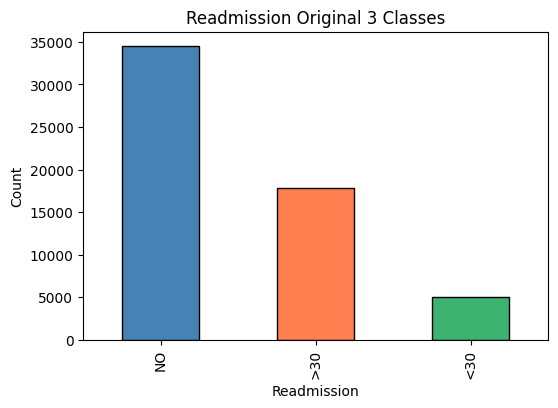

In [39]:
# we first examine the distribution of 'readmitted' across its original 3 classes
plt.figure(figsize=(6,4))

df['readmitted'].value_counts().plot(kind='bar', color=['steelblue','coral','mediumseagreen'], edgecolor='black')

plt.title('Readmission Original 3 Classes')
plt.xlabel('Readmission')
plt.ylabel('Count')
plt.show()

In [40]:
print("Target distribution")
target_counts = df["readmitted_binary"].value_counts()
target_pct = df["readmitted_binary"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": target_counts, "percent": target_pct.round(2)}))

Target distribution
                   count  percent
readmitted_binary                
0                  34493    60.09
1                  22913    39.91


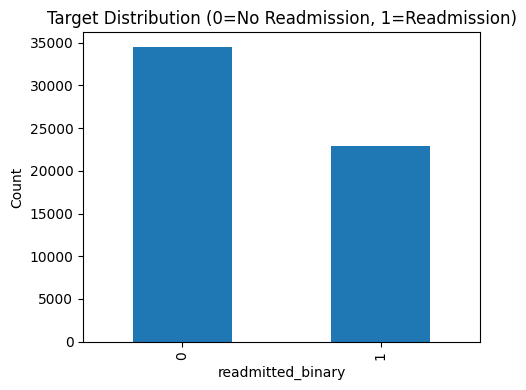

In [41]:
plt.figure(figsize=(5,4))
target_counts.sort_index().plot(kind="bar")
plt.title("Target Distribution (0=No Readmission, 1=Readmission)")
plt.xlabel("readmitted_binary")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

###**Patient Demographics:**

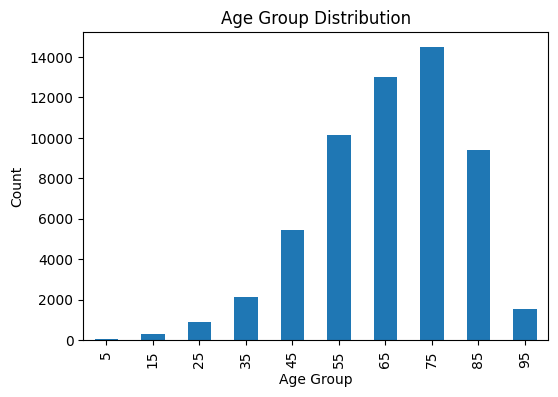

In [42]:
# next, we explore the distributions of age, gender, and race.
# these are clinically relevant because older patients and certain demographic groups
# face higher risks of diabetes complications and readmission

# age distribution
plt.figure(figsize=(6,4))

age_order = sorted(df['age'].dropna().unique())
df['age'].value_counts().reindex(age_order).plot(kind='bar')

plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

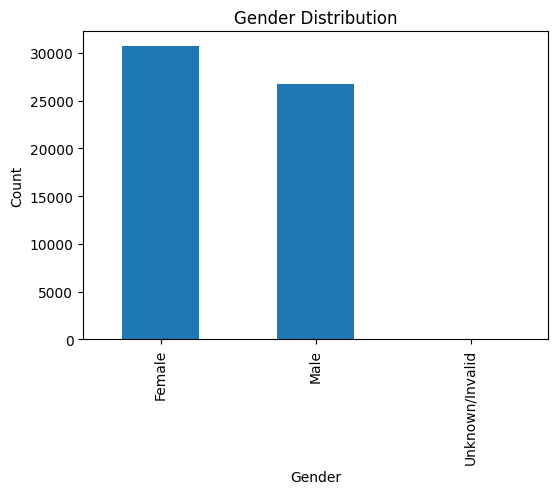

In [43]:
# gender distribution
plt.figure(figsize=(6,4))

df['gender'].value_counts().plot(kind='bar')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

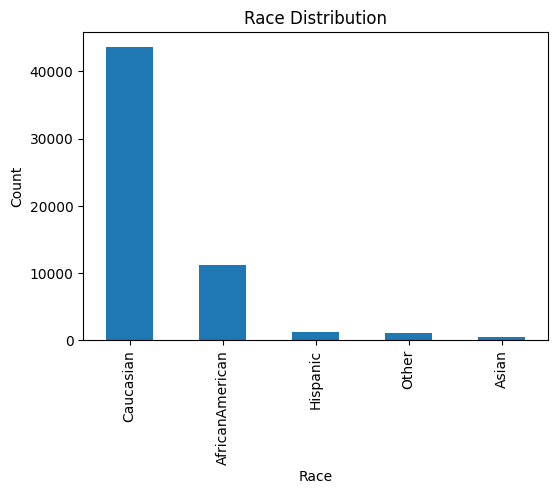

In [44]:
# race distribution
plt.figure(figsize=(6,4))

df['race'].value_counts().plot(kind='bar')

plt.title('Race Distribution')
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

###**Readmission Rate by Age Group:**

In [45]:
print("Readmission by age")
age_rate = df.groupby("age")["readmitted_binary"].mean().sort_index() * 100
print(age_rate.round(2))

Readmission by age
age
5     22.03
15    33.77
25    30.81
35    32.56
45    35.86
55    36.82
65    39.75
75    43.60
85    43.92
95    34.00
Name: readmitted_binary, dtype: float64


/tmp/ipykernel_46729/191555195.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate = df.groupby("age")["readmitted_binary"].mean().sort_index() * 100


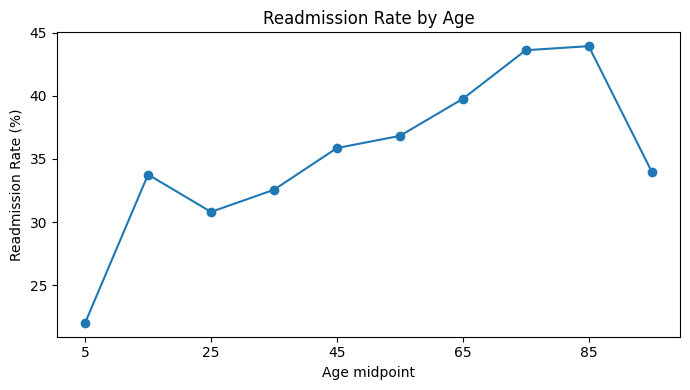

In [46]:
plt.figure(figsize=(7,4))
age_rate.plot(marker="o")
plt.title("Readmission Rate by Age")
plt.xlabel("Age midpoint")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

In [47]:
print("Readmission rate by time in hospital")
stay_rate = df.groupby("time_in_hospital")["readmitted_binary"].mean() * 100
print(stay_rate.round(2).head(20))

Readmission rate by time in hospital
time_in_hospital
1     34.05
2     38.14
3     38.93
4     41.40
5     41.64
6     42.75
7     43.91
8     43.83
9     44.08
10    43.78
11    42.44
12    44.04
Name: readmitted_binary, dtype: float64


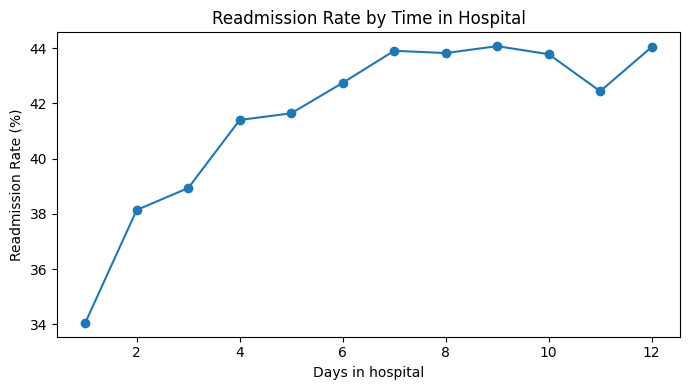

In [48]:
plt.figure(figsize=(7,4))
stay_rate.plot(marker="o")
plt.title("Readmission Rate by Time in Hospital")
plt.xlabel("Days in hospital")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

###**Clinical Visit Characteristics:**

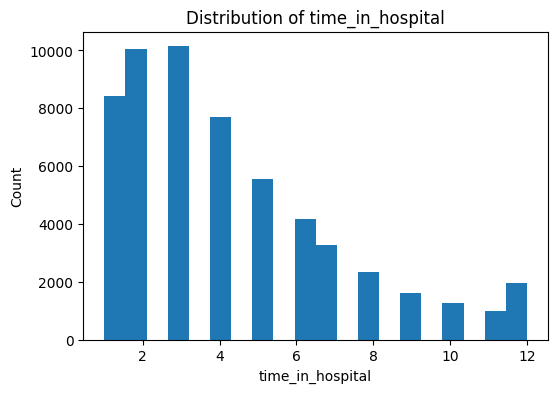

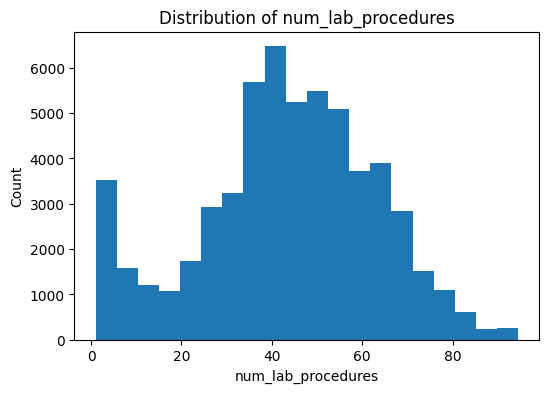

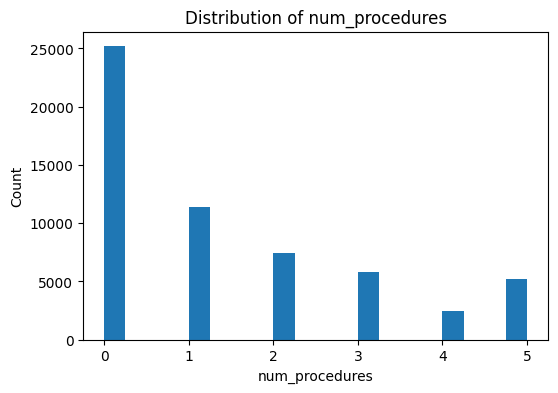

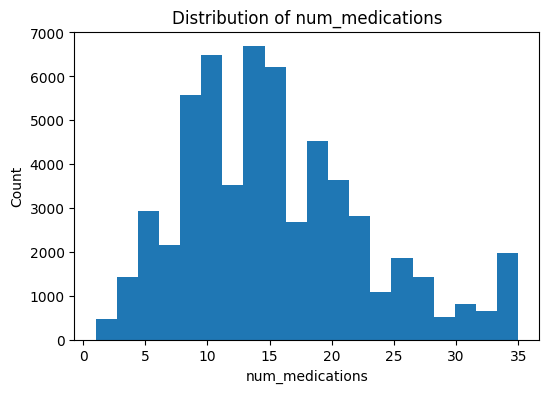

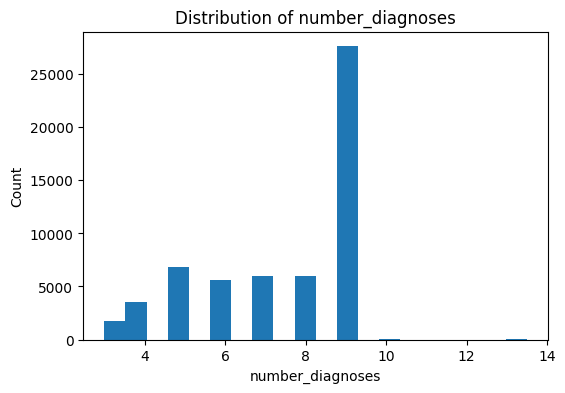

In [49]:
# then we look at the distributions of key numeric variables:
# time in hospital, number of lab procedures, procedures, medications, and diagnoses.
# these reflect the severity and complexity of each encounter and are likely predictive of readmission.

numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']

for c in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[c].dropna(), bins=20)
    plt.title(f'Distribution of {c}')
    plt.xlabel(c)
    plt.ylabel('Count')
    plt.show()

In [50]:
display(df[numeric_cols].describe().round(2))

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses
count,57406.00,57406.00,57406.00,57406.00,57406.00
mean,4.27,43.44,1.38,15.50,7.43
std,2.86,19.71,1.63,7.45,1.87
min,1.00,1.00,0.00,1.00,3.00
25%,2.00,32.00,0.00,10.00,6.00
50%,4.00,44.00,1.00,14.00,8.00
75%,6.00,57.00,2.00,20.00,9.00
max,12.00,94.50,5.00,35.00,13.50


###**Prior Visit History and Readmission:**

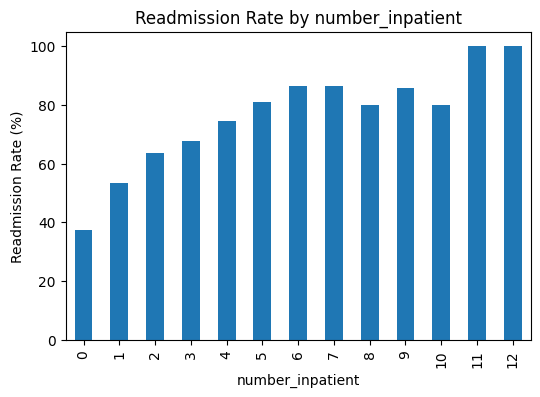

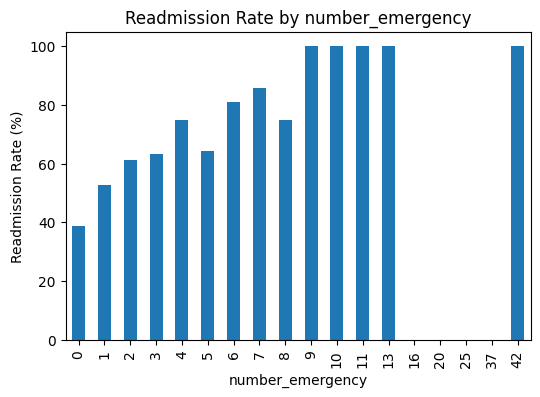

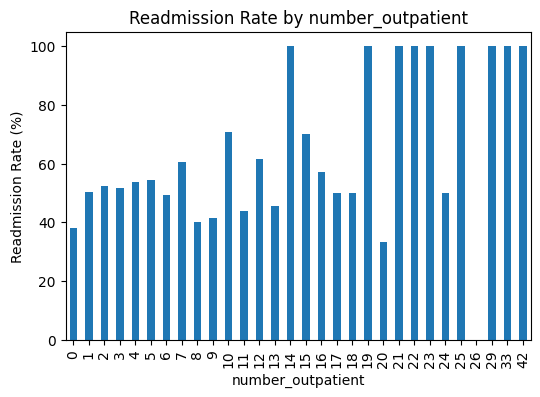

In [51]:
# then a patient's history of previous inpatient, emergency, and outpatient visits
# may signal chronic instability, which would increase readmission risk.

visit_cols = ['number_inpatient', 'number_emergency', 'number_outpatient']

for c in visit_cols:
    plt.figure(figsize=(6,4))

    rate = df.groupby(c)['readmitted_binary'].mean() * 100
    rate.plot(kind='bar')

    plt.title(f'Readmission Rate by {c}')
    plt.xlabel(c)
    plt.ylabel('Readmission Rate (%)')
    plt.show()

###**Treatments:**

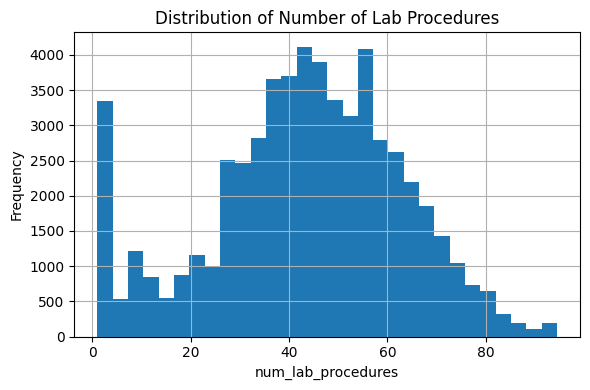

In [52]:
plt.figure(figsize=(6,4))
df["num_lab_procedures"].hist(bins=30)
plt.title("Distribution of Number of Lab Procedures")
plt.xlabel("num_lab_procedures")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

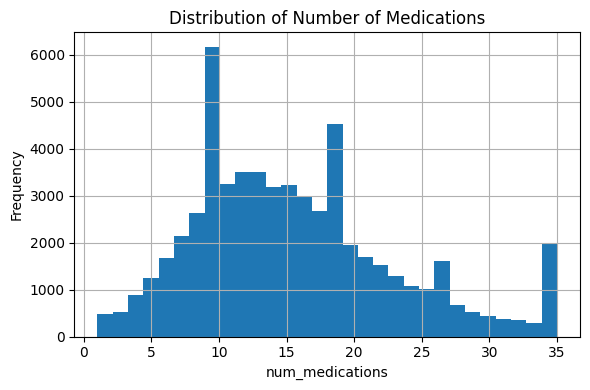

In [53]:
plt.figure(figsize=(6,4))
df["num_medications"].hist(bins=30)
plt.title("Distribution of Number of Medications")
plt.xlabel("num_medications")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

/tmp/ipykernel_46729/1734349173.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  insulin_readmit = df.groupby('insulin')['readmitted_binary'].mean() * 100


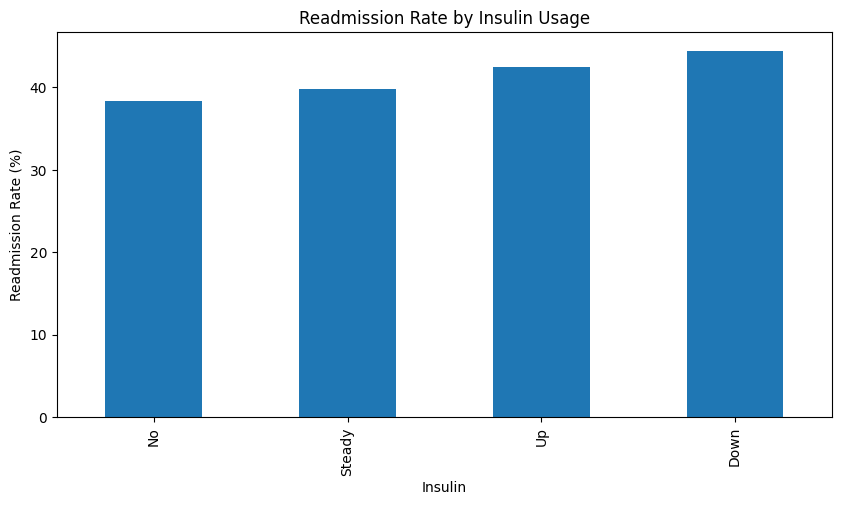

In [54]:
# insulin is the primary medication for managing blood sugar in diabetic patients
# so we examine whether changes in insulin dosage during the visit
# (Up, Down, Steady, No) are associated with different readmission rates

insulin_readmit = df.groupby('insulin')['readmitted_binary'].mean() * 100

plt.figure(figsize=(10, 5))

insulin_readmit.sort_values().plot(kind='bar')

plt.title('Readmission Rate by Insulin Usage')
plt.xlabel('Insulin')
plt.ylabel('Readmission Rate (%)')
plt.show()

In [55]:
display(insulin_readmit.round(2))

,readmitted_binary
insulin,
Down,44.48
No,38.39
Steady,39.84
Up,42.48


### **Key Insights from Part 3:**

- **Target variable is relatively balanced (binary):** After converting to binary (0 for no readmission, 1 for readmission before and after the month period), 60.09% (34,493) are not readmitted and 39.91% (22,913) are readmitted which is a relatively balanced split favorable for modeling.

- **Age and readmission show a non linear relationship:** The youngest group (age 5) has the lowest readmission rate (22.03%). Rate rises sharply to 30-33% by age 15-25, then gradually increases to peak at 85 years (43.92%). Elderly patients (75-85) consistently show the highest readmission risk, consistent with greater clinical complexity.

- **Prior inpatient visits are the strongest signal:** Readmission rates rise steadily from 40% (0 prior visits) to nearly 100% (11+ visits). **number_inpatient** has the highest correlation with the target (0.217). Prior emergency visits rise even faster. A patient's hospital history is the most informative feature group.

- **Clinical complexity drives readmission:** Longer hospital stays correlate with higher readmission rising from 40% (1 day) to 44% (8+ days). **num_lab_procedures** follows a normal distribution centered around 40-50. Similarly, **num_medications** shows a normal distribution however peaking at 10 and 20, suggesting two distinct patient groups (mild vs complex diabetes management). **number_diagnoses** spikes sharply at 9 the most common value.

- **Insulin adjustment is strongly associated with higher readmission:** Patients with no insulin or steady dose (38-39%) show lower readmission rates. Any dose change increases risk:
  - **Up**: 42% so blood sugar uncontrolled, dose increased
  - **Down**: 44% so highest risk, suggests dangerous instability in diabetes management

- **The dataset is demographically skewed:** Over 70% of patients are Caucasian (approximately 44,000), with AfricanAmerican being a distant second (approx 10,000). The majority are aged 65-80 (peak at 75). Gender is relatively balanced (Female slightly more than Male). This demographic skewness limits generalizability to younger or more diverse populations. As such, we don't need to correct the skewness as our data and models are non linear.

- **All correlations are weak (below 0.22):** No single feature dominates readmission prediction. **number_inpatient** is at 0.217, followed by **number_diagnoses** (0.112) and **number_emergency** (0.105). Readmission is driven by complex interactions between multiple features which justifys the use of ensemble models like XGBoost over simple linear models.

- **Diagnosis columns have extremely high cardinality:** **diag_1**, **diag_2**, **diag_3** have 716-789 unique ICD codes each thus direct encoding would be impractical. These will require grouping into broader disease categories in feature engineering.

## **4. Feature engineering & selection:**

###**Feature engineering:**

In [56]:
med_cols = [
    "metformin","repaglinide","nateglinide","chlorpropamide","glimepiride","acetohexamide",
    "glipizide","glyburide","tolbutamide","pioglitazone","rosiglitazone","acarbose","miglitol",
    "troglitazone","tolazamide","examide","citoglipton","insulin","glyburide_metformin",
    "glipizide_metformin","glimepiride_pioglitazone","metformin_rosiglitazone","metformin_pioglitazone"
]

df["num_med_changed"] = 0
for col in med_cols:
  df["num_med_changed"] += df[col].isin(["Up", "Down", "Steady"]).astype(int)

In [57]:
intensity_cols = ["num_lab_procedures", "num_procedures", "num_medications"]

df["treatment_intensity"] = df[intensity_cols].sum(axis=1)

In [58]:
df["emergency_admission"] = (df["admission_type_id"] == "Emergency").astype(int)

df["discharged_home"] = (df["discharge_disposition_id"] == "Home").astype(int)

df["admitted_from_er"] = (df["admission_source_id"] == "Emergency").astype(int)

df["diabetesmed_yes"] = (df["diabetesmed"] == "Yes").astype(int)

df["change_yes"] = (df["change"] == "Ch").astype(int)

In [59]:
visit_cols = ["number_outpatient", "number_emergency", "number_inpatient"]
df["total_visits"] = df["number_outpatient"] + df["number_emergency"] + df["number_inpatient"]

In [60]:
X = df.drop(columns=['readmitted', 'readmitted_binary'])
y = df['readmitted_binary']

# First split: 80% train_temp, 20% test
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Second split: 80% train, 20% validation (from train_temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(36739, 52) (9185, 52) (11482, 52)


### **Scaling:**

In [61]:
numeric = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

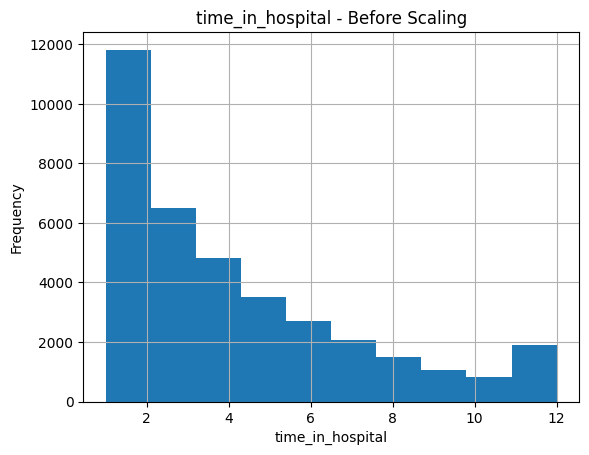

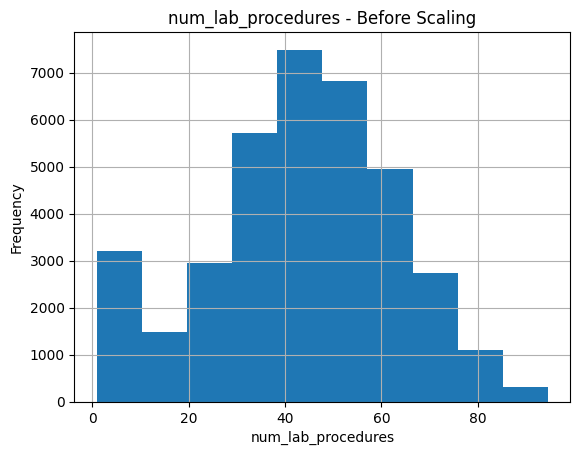

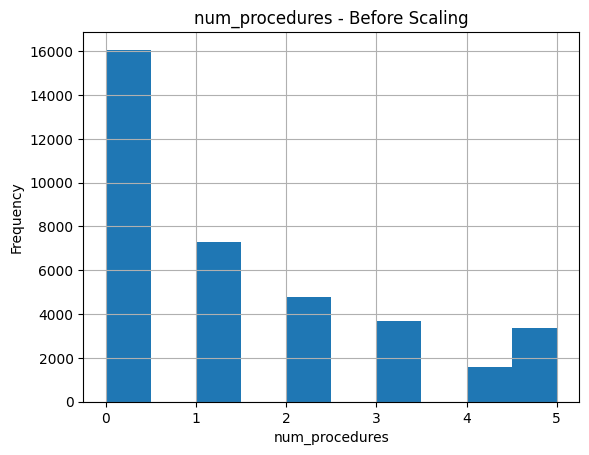

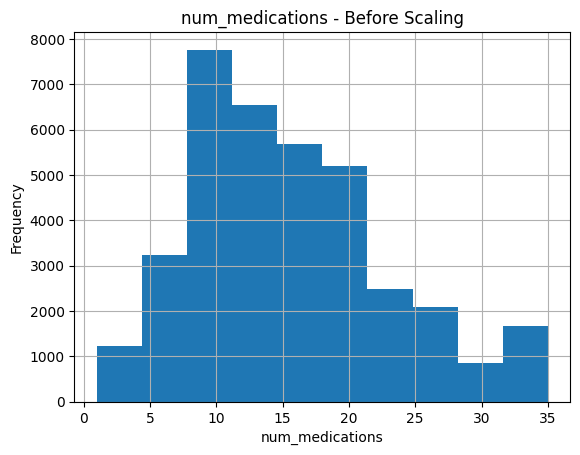

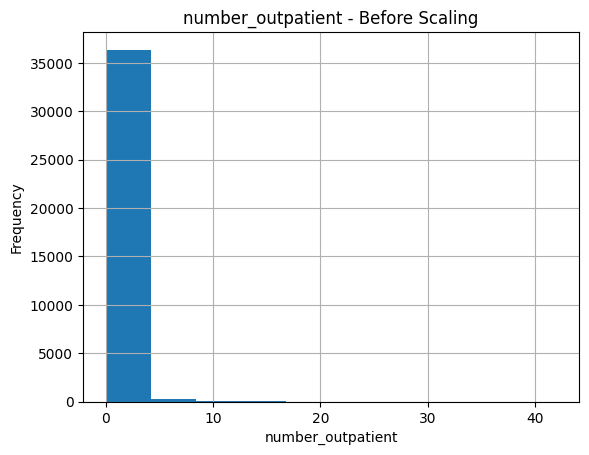

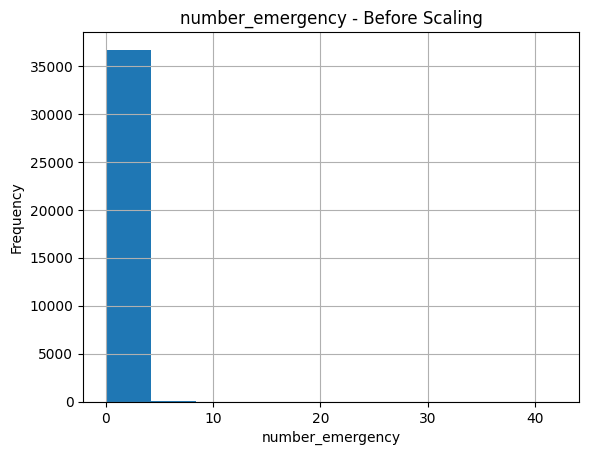

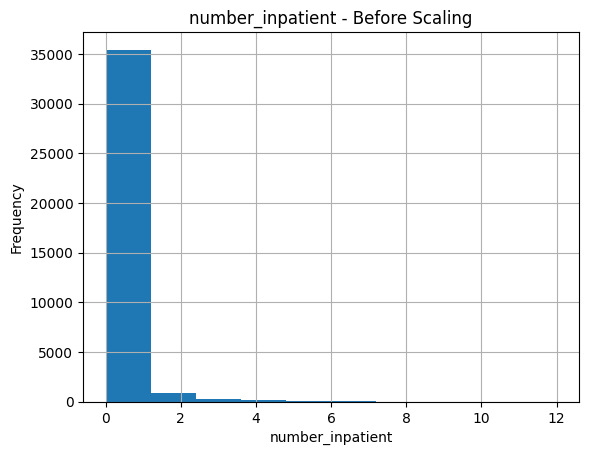

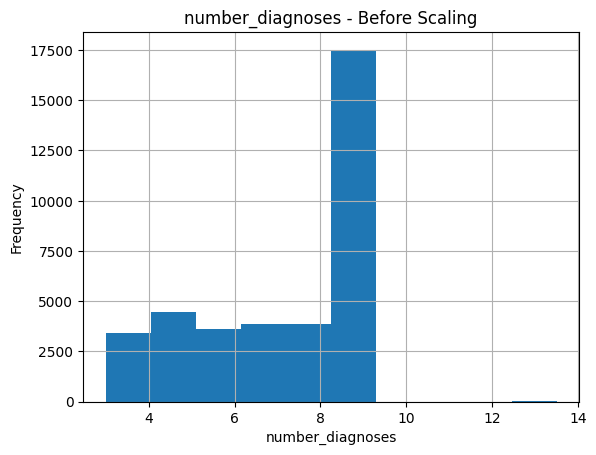

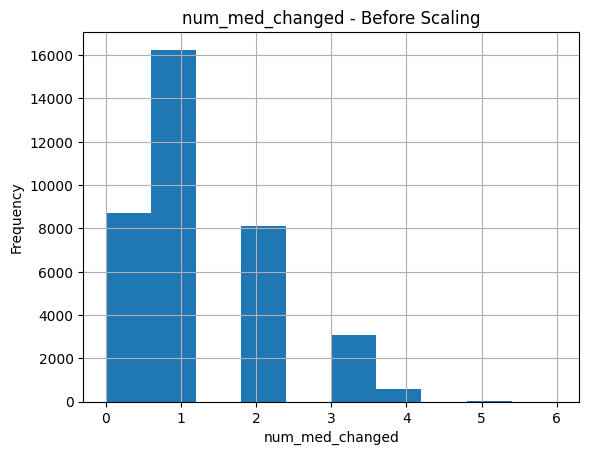

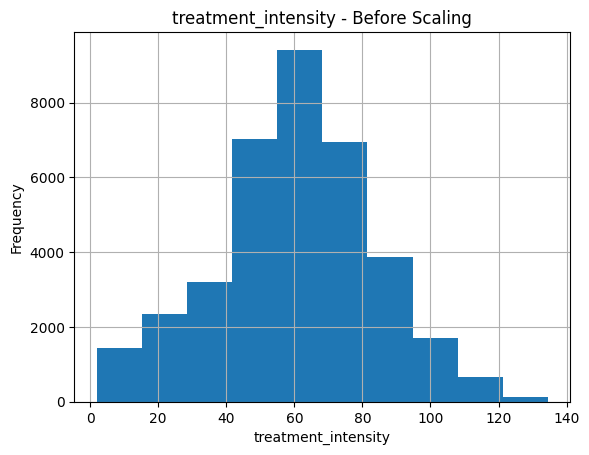

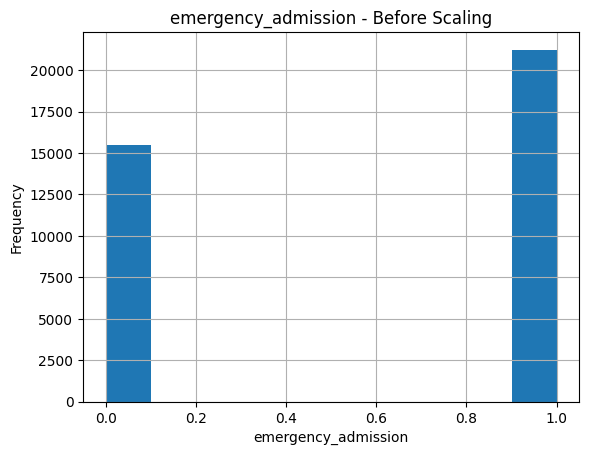

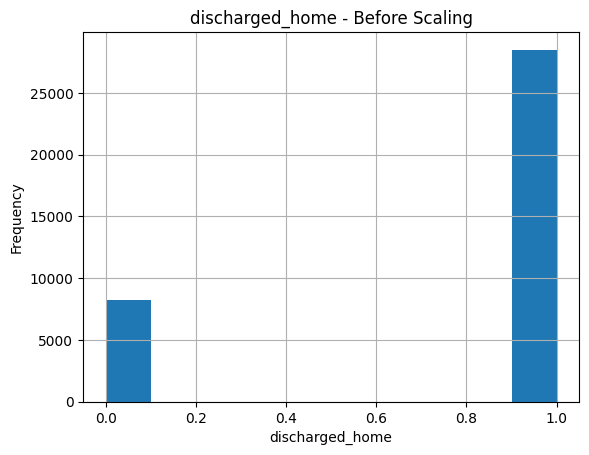

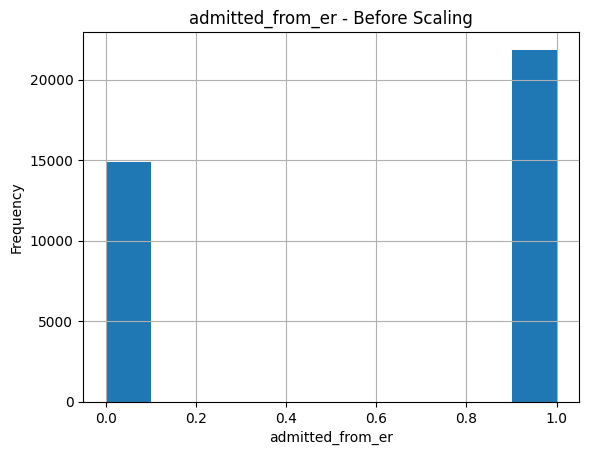

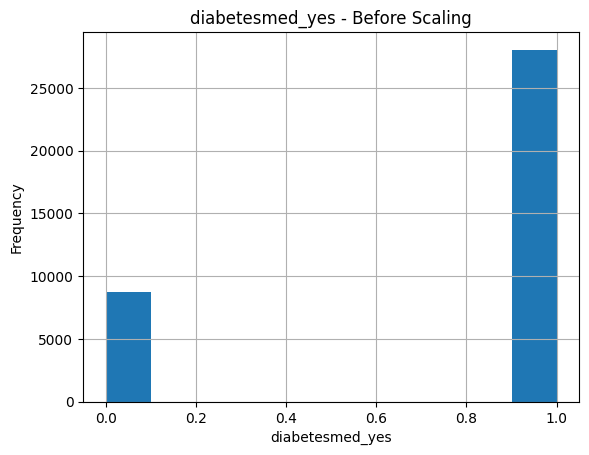

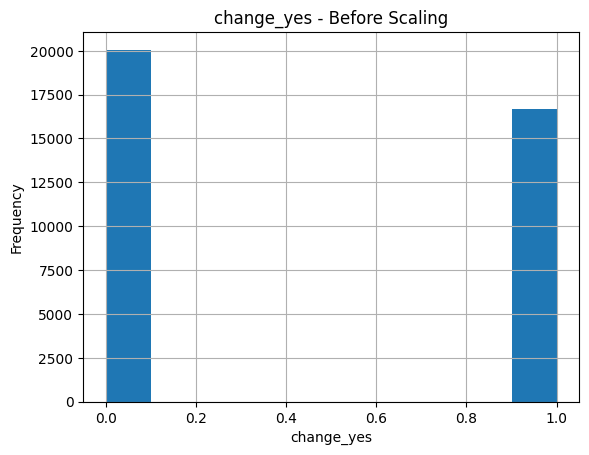

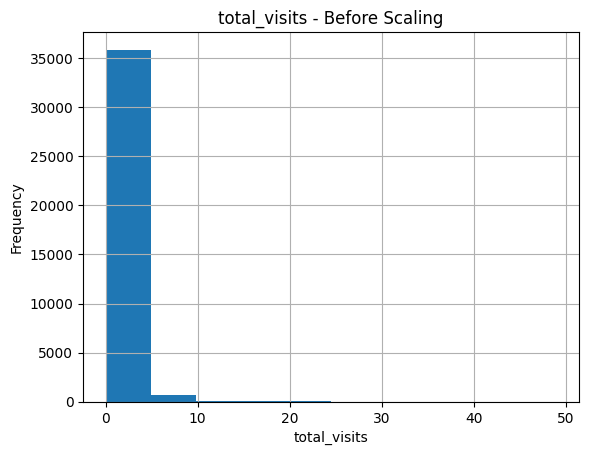

In [62]:
for col in numeric:
    plt.figure()
    X_train[col].hist()
    plt.title(f"{col} - Before Scaling")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [63]:
scaler = MinMaxScaler()
X_train[numeric] = scaler.fit_transform(X_train[numeric])
X_val[numeric] = scaler.transform(X_val[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])

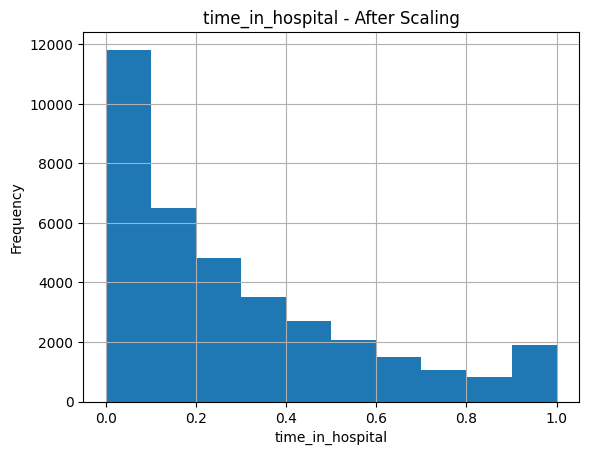

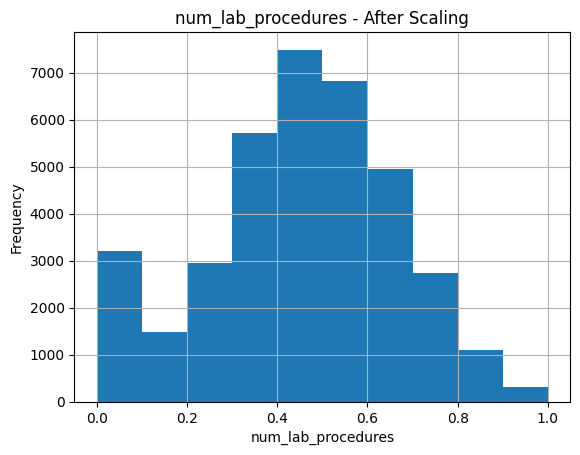

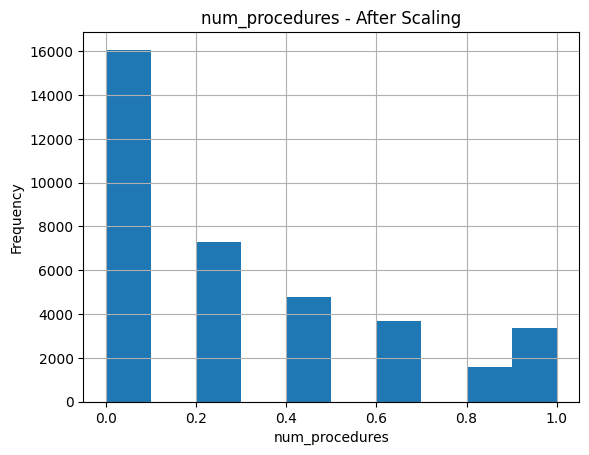

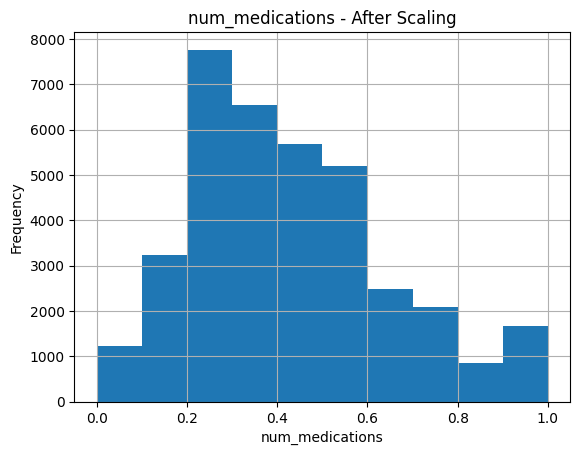

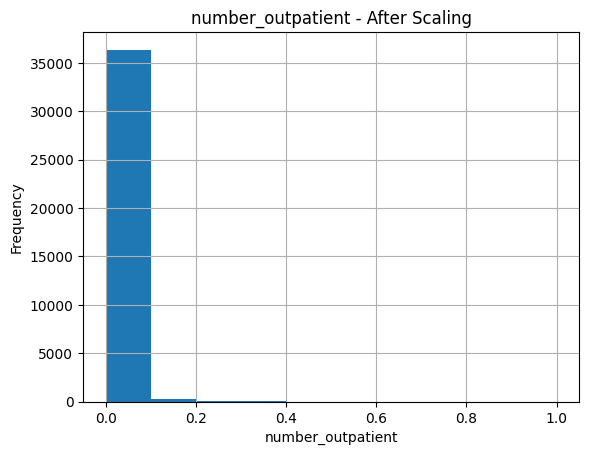

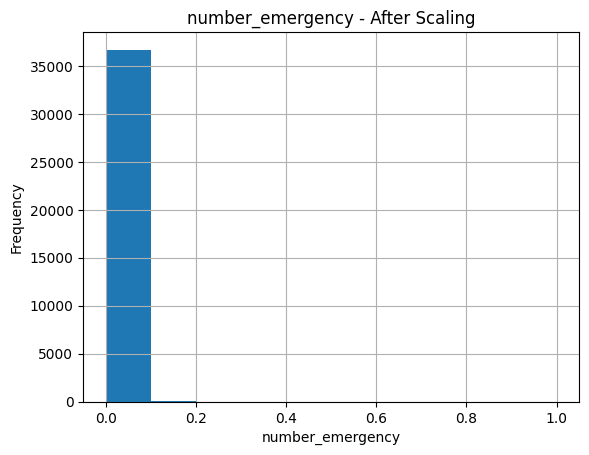

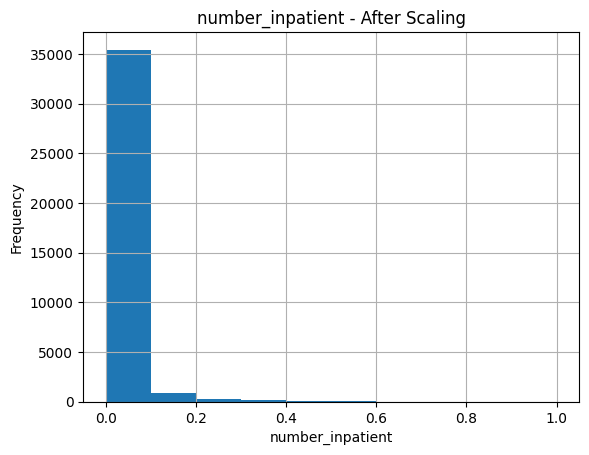

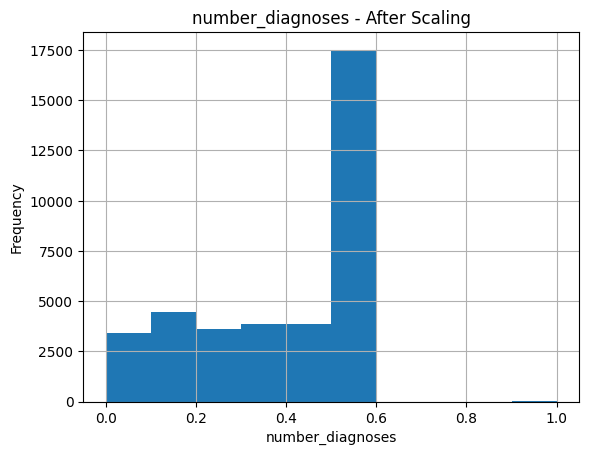

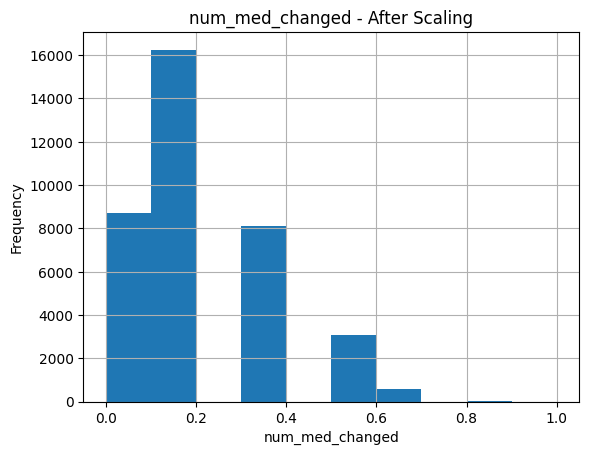

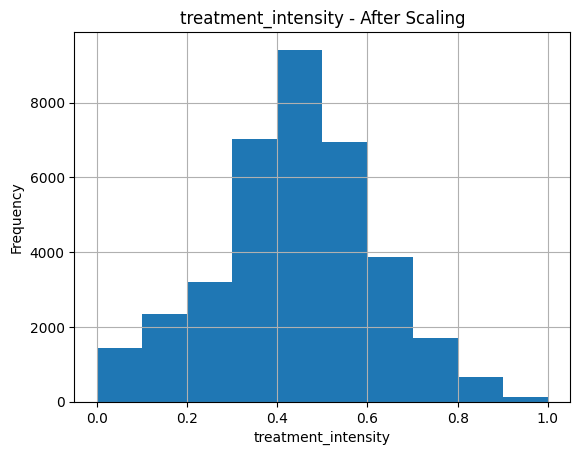

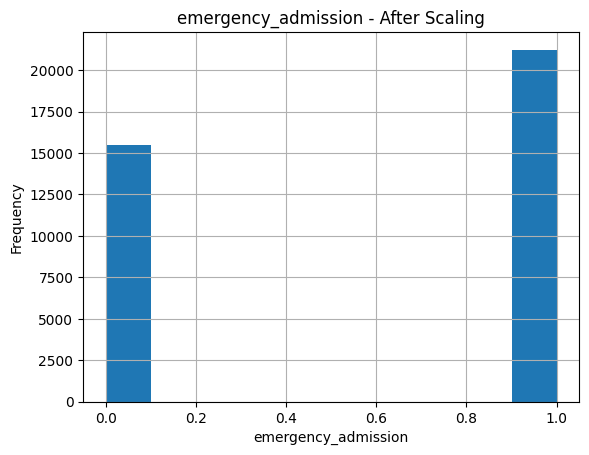

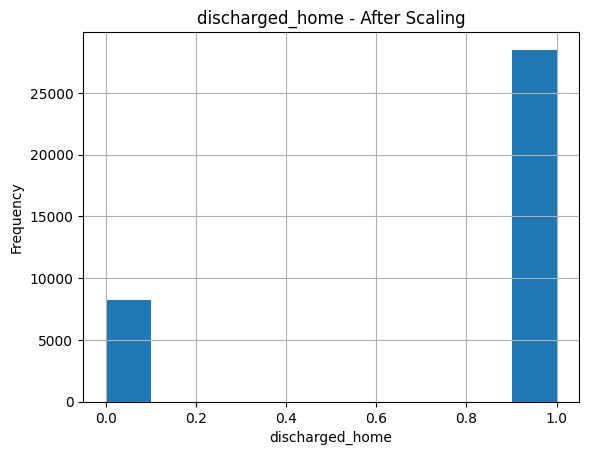

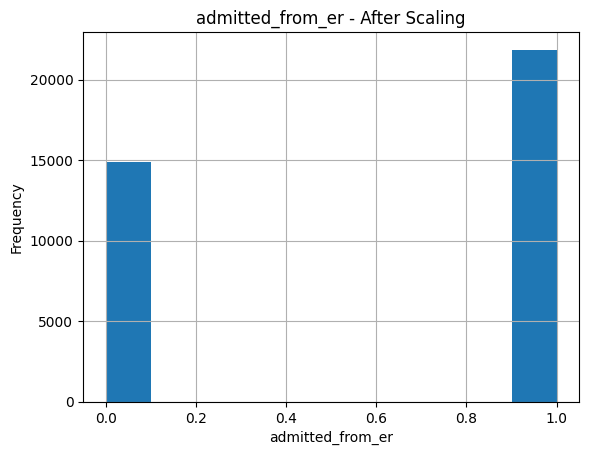

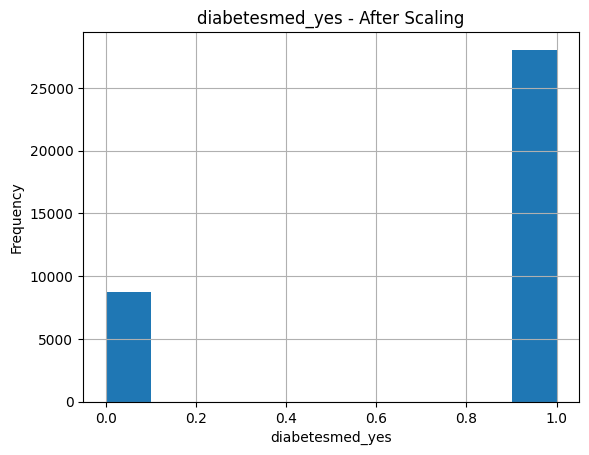

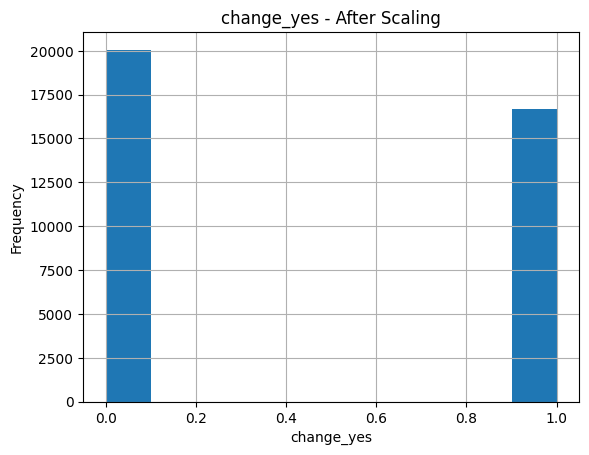

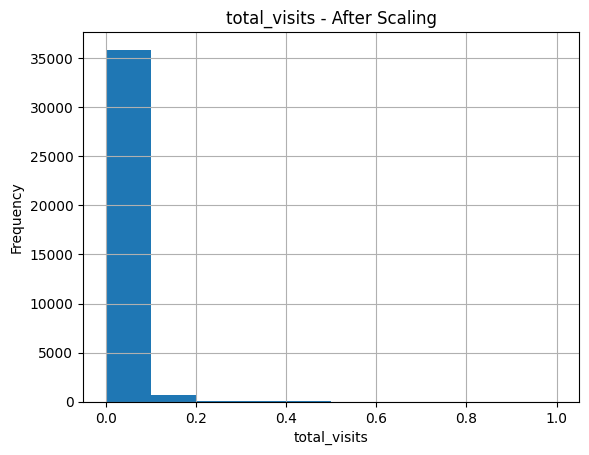

In [64]:
for col in numeric:
    plt.figure()
    X_train[col].hist()
    plt.title(f"{col} - After Scaling")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### **Feature selection:**

In [65]:
# correlation with target from training data only
train_corr_df = pd.concat([X_train, y_train], axis=1)
corr_with_target = train_corr_df.corr(numeric_only=True)["readmitted_binary"].abs()

# keep only numerical training features
num_train = X_train.select_dtypes(include=["int64", "float64"])

# correlation matrix between features
corr_matrix = num_train.corr().abs()

# upper triangle only
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = []

for col in upper.columns:
    high_corr_features = upper.index[upper[col] > 0.8].tolist()

    for row in high_corr_features:
        if corr_with_target[row] < corr_with_target[col]:
            drop_feature = row
        else:
            drop_feature = col

        if drop_feature not in to_drop:
            to_drop.append(drop_feature)

# drop from all splits
X_train = X_train.drop(columns=to_drop, errors="ignore")
X_val = X_val.drop(columns=to_drop, errors="ignore")
X_test = X_test.drop(columns=to_drop, errors="ignore")

print("Dropped columns:", to_drop)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

Dropped columns: ['num_lab_procedures']
X_train shape: (36739, 51)
X_val shape: (9185, 51)
X_test shape: (11482, 51)


In [66]:
train_corr_df = pd.concat([X_train, y_train], axis=1)
corr_with_target = train_corr_df.corr(numeric_only=True)["readmitted_binary"].abs().sort_values(ascending=False)

selected_features = corr_with_target[corr_with_target > 0.01].index.tolist()
selected_features = [col for col in selected_features if col != "readmitted_binary"]

X_train = X_train[selected_features]
X_val = X_val[selected_features]
X_test = X_test[selected_features]

print("Selected features:", selected_features)
print("Final X_train shape:", X_train.shape)

Selected features: ['total_visits', 'number_inpatient', 'number_diagnoses', 'number_emergency', 'admitted_from_er', 'number_outpatient', 'diabetesmed_yes', 'time_in_hospital', 'change_yes', 'num_med_changed', 'num_medications', 'treatment_intensity', 'num_procedures', 'emergency_admission']
Final X_train shape: (36739, 14)


In [67]:
print("Number of selected features:")
print(len(selected_features))

print("\nTop selected features:")
print(corr_with_target.head(20))

Number of selected features:
14

Top selected features:
readmitted_binary      1.000000
total_visits           0.130404
number_inpatient       0.129017
number_diagnoses       0.100068
number_emergency       0.073217
admitted_from_er       0.069655
number_outpatient      0.066995
diabetesmed_yes        0.065650
time_in_hospital       0.056540
change_yes             0.043890
num_med_changed        0.041421
num_medications        0.038076
treatment_intensity    0.031710
num_procedures         0.029079
emergency_admission    0.028098
discharged_home        0.002144
Name: readmitted_binary, dtype: float64


In [68]:
# class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("Scale positive weight:", scale_pos_weight)

Scale positive weight: 1.5053873431533007


### **Key Insights from Part 4:**

- **8 new features were engineered** to capture clinical patterns
  not directly available in the raw data:
  - **num_med_changed**: counts how many medications were actively used (Steady/Up/Down) across all 23 medication columns
  - **treatment_intensity**: sum of lab procedures, procedures, and medications — captures overall clinical complexity
  - **emergency_admission**: binary flag for emergency admissions
  - **discharged_home**: binary flag for patients discharged home
  - **admitted_from_er**: binary flag for ER admissions
  - **diabetesmed_yes**: binary flag for diabetes medication usage
  - **change_yes**: binary flag for any medication change
  - **total_visits**: sum of all prior visit types (inpatient + emergency + outpatient) to captures full hospital history

- **MinMaxScaler applied** to all numeric columns bringing all features to 0-1 range. fit_transform is applied only to training data to prevent data leakage; val and test sets use the same scaler parameters.

- **Correlation-based feature selection** First we remove the least correlated feature with the target from pairs having > 0.8 correlation. Then, we select features with correlation > 0.01. This threshold was chosen because all features in this dataset have inherently low correlations (max 0.22) letting XGBoost handle the actual feature weighting through its built in importance mechanism:
  - **number_inpatient** (0.129): 2nd strongest predictor
  - **total_visits** (0.13): engineered feature ranks 1st!
  - **number_diagnoses** (0.1), **number_emergency** (0.073) follow as strong clinical signals
  - All 5 engineered features passed selection threshold validating the feature engineering decisions

- **Features dropped** by selection (correlation ≤ 0.01):
  - **num_lab_procedures**: by high correlation with the features
  - **race, diag_1/2/3**, **most individual medication columns**: these add noise rather than signal

- **Dataset split into 3 sets** with stratification:
  - Train: 36739 rows (64%)
  - Validation: 9185 rows (16%)  
  - Test: 11482 rows (20%)
  - **stratify=y** ensures equal class ratio across all splits


# ***Milestone 3: Data Modeling & Evaluation***


---



## **5. Modeling & Evaluation**

###**Metrics:**


In [69]:
def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    f2 = fbeta_score(y_true, y_pred, beta=2)
    auc = roc_auc_score(y_true, y_prob)
    return acc, f2, auc

In [70]:
def bootstrap_ci(y_true, y_pred, y_prob, n_boot=500, seed=42):
    rng = np.random.default_rng(seed)
    accs = []
    f2s = []
    aucs = []

    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    y_prob_np = np.array(y_prob)

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true_np), len(y_true_np))

        y_b = y_true_np[idx]
        pred_b = y_pred_np[idx]
        prob_b = y_prob_np[idx]

        if len(np.unique(y_b)) < 2:
            continue

        accs.append(accuracy_score(y_b, pred_b))
        f2s.append(fbeta_score(y_b, pred_b, beta=2))
        aucs.append(roc_auc_score(y_b, prob_b))

    acc_ci = (np.percentile(accs, 2.5), np.percentile(accs, 97.5))
    f2_ci = (np.percentile(f2s, 2.5), np.percentile(f2s, 97.5))
    auc_ci = (np.percentile(aucs, 2.5), np.percentile(aucs, 97.5))

    return acc_ci, f2_ci, auc_ci

results = []

### **Baseline:**

In [71]:
# majority class: baseline = [y_train.mode()[0]] * len(y_test)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_prob = np.zeros(len(y_test))
baseline_acc, baseline_f2, baseline_auc = compute_metrics(y_test, baseline_pred, baseline_prob)
baseline_acc_ci, baseline_f2_ci, baseline_auc_ci = bootstrap_ci(y_test, baseline_pred, baseline_prob)

results.append({
    "Model": "Baseline (Most Frequent)",
    "Accuracy": baseline_acc,
    "Accuracy_CI": baseline_acc_ci,
    "F2": baseline_f2,
    "F2_CI": baseline_f2_ci,
    "AUC": baseline_auc,
    "AUC_CI": baseline_auc_ci
})

### **Random Forest:**

In [72]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

rf_acc, rf_f2, rf_auc = compute_metrics(y_test, rf_pred, rf_prob)
rf_acc_ci, rf_f2_ci, rf_auc_ci = bootstrap_ci(y_test, rf_pred, rf_prob)

results.append({
    "Model": "Random Forest",
    "Accuracy": rf_acc,
    "Accuracy_CI": rf_acc_ci,
    "F2": rf_f2,
    "F2_CI": rf_f2_ci,
    "AUC": rf_auc,
    "AUC_CI": rf_auc_ci
})

### **XGBoost:**

In [73]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_pred = xgb.predict(X_test)

xgb_acc, xgb_f2, xgb_auc = compute_metrics(y_test, xgb_pred, xgb_prob)
xgb_acc_ci, xgb_f2_ci, xgb_auc_ci = bootstrap_ci(y_test, xgb_pred, xgb_prob)

results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_acc,
    "Accuracy_CI": xgb_acc_ci,
    "F2": xgb_f2,
    "F2_CI": xgb_f2_ci,
    "AUC": xgb_auc,
    "AUC_CI": xgb_auc_ci
})

## **6. Results & Discussions**

### **Results:**

In [74]:
results_df = pd.DataFrame(results)

print("Model Comparison:")
for i in range(len(results_df)):
    print("\nModel:", results_df.loc[i, "Model"])

    acc_ci = results_df.loc[i, "Accuracy_CI"]
    f2_ci = results_df.loc[i, "F2_CI"]
    auc_ci = results_df.loc[i, "AUC_CI"]

    print(
        "Accuracy:", round(results_df.loc[i, "Accuracy"], 4),
        "| 95% CI:", tuple(np.round(acc_ci, 4)) if isinstance(acc_ci, (tuple, list, np.ndarray)) else acc_ci
    )
    print(
        "F2:", round(results_df.loc[i, "F2"], 4),
        "| 95% CI:", tuple(np.round(f2_ci, 4)) if isinstance(f2_ci, (tuple, list, np.ndarray)) else f2_ci
    )
    print(
        "AUC:", round(results_df.loc[i, "AUC"], 4),
        "| 95% CI:", tuple(np.round(auc_ci, 4)) if isinstance(auc_ci, (tuple, list, np.ndarray)) else auc_ci
    )

Model Comparison:

Model: Baseline (Most Frequent)
Accuracy: 0.6009 | 95% CI: (np.float64(0.5924), np.float64(0.609))
F2: 0.0 | 95% CI: (np.float64(0.0), np.float64(0.0))
AUC: 0.5 | 95% CI: (np.float64(0.5), np.float64(0.5))

Model: Random Forest
Accuracy: 0.5791 | 95% CI: (np.float64(0.5702), np.float64(0.5878))
F2: 0.3637 | 95% CI: (np.float64(0.351), np.float64(0.3769))
AUC: 0.5712 | 95% CI: (np.float64(0.5611), np.float64(0.5816))

Model: XGBoost
Accuracy: 0.5873 | 95% CI: (np.float64(0.5769), np.float64(0.5962))
F2: 0.5703 | 95% CI: (np.float64(0.5573), np.float64(0.5825))
AUC: 0.6291 | 95% CI: (np.float64(0.6181), np.float64(0.6394))



Confusion Matrix for Random Forest:


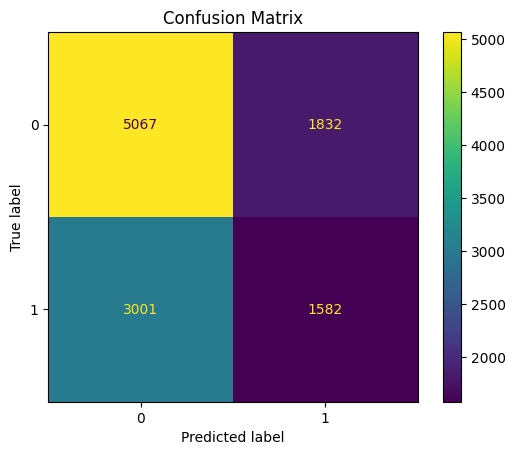


Confusion Matrix for XGBoost:


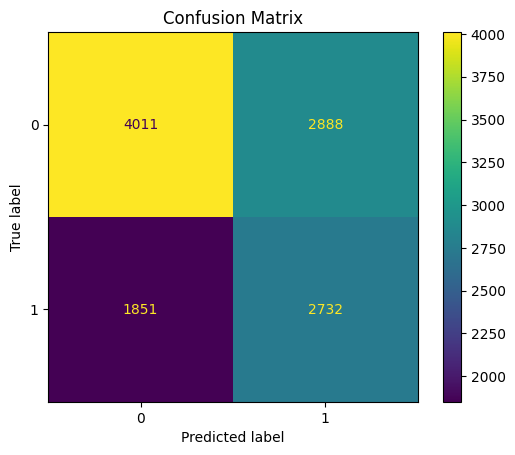

In [75]:
cm = confusion_matrix(y_test, rf_pred)
print("\nConfusion Matrix for Random Forest:")
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

cm = confusion_matrix(y_test, xgb_pred)
print("\nConfusion Matrix for XGBoost:")
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

In [76]:
best_model = results_df.sort_values("F2", ascending=False).iloc[0]["Model"]
print("Best model by F2:", best_model)

Best model by F2: XGBoost


### **Tuning the best model:**

In [77]:
xgb_tuned = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=1,
    reg_lambda=2,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

# threshold tuning on validation for F2
val_prob = xgb_tuned.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.10, 0.91, 0.05)
best_threshold = 0.5
best_val_f2 = -1

for t in thresholds:
    val_pred = (val_prob >= t).astype(int)
    val_f2 = fbeta_score(y_val, val_pred, beta=2)
    if val_f2 > best_val_f2:
        best_val_f2 = val_f2
        best_threshold = t

xgb_tuned_prob = xgb_tuned.predict_proba(X_test)[:, 1]
xgb_tuned_pred = (xgb_tuned_prob >= best_threshold).astype(int)

xgb_tuned_acc, xgb_tuned_f2, xgb_tuned_auc = compute_metrics(y_test, xgb_tuned_pred, xgb_tuned_prob)
xgb_tuned_acc_ci, xgb_tuned_f2_ci, xgb_tuned_auc_ci = bootstrap_ci(y_test, xgb_tuned_pred, xgb_tuned_prob)

results.append({
    "Model": f"XGBoost After Tuning (threshold={best_threshold:.2f})",
    "Accuracy": xgb_tuned_acc,
    "Accuracy_CI": xgb_tuned_acc_ci,
    "F2": xgb_tuned_f2,
    "F2_CI": xgb_tuned_f2_ci,
    "AUC": xgb_tuned_auc,
    "AUC_CI": xgb_tuned_auc_ci
})

In [78]:
results_df = pd.DataFrame(results)

print("Model Comparison:")
for i in range(len(results_df)):
    print("\nModel:", results_df.loc[i, "Model"])

    acc_ci = results_df.loc[i, "Accuracy_CI"]
    f2_ci = results_df.loc[i, "F2_CI"]
    auc_ci = results_df.loc[i, "AUC_CI"]

    print(
        "Accuracy:", round(results_df.loc[i, "Accuracy"], 4),
        "| 95% CI:", tuple(np.round(acc_ci, 4)) if isinstance(acc_ci, (tuple, list, np.ndarray)) else acc_ci
    )
    print(
        "F2:", round(results_df.loc[i, "F2"], 4),
        "| 95% CI:", tuple(np.round(f2_ci, 4)) if isinstance(f2_ci, (tuple, list, np.ndarray)) else f2_ci
    )
    print(
        "AUC:", round(results_df.loc[i, "AUC"], 4),
        "| 95% CI:", tuple(np.round(auc_ci, 4)) if isinstance(auc_ci, (tuple, list, np.ndarray)) else auc_ci
    )

Model Comparison:

Model: Baseline (Most Frequent)
Accuracy: 0.6009 | 95% CI: (np.float64(0.5924), np.float64(0.609))
F2: 0.0 | 95% CI: (np.float64(0.0), np.float64(0.0))
AUC: 0.5 | 95% CI: (np.float64(0.5), np.float64(0.5))

Model: Random Forest
Accuracy: 0.5791 | 95% CI: (np.float64(0.5702), np.float64(0.5878))
F2: 0.3637 | 95% CI: (np.float64(0.351), np.float64(0.3769))
AUC: 0.5712 | 95% CI: (np.float64(0.5611), np.float64(0.5816))

Model: XGBoost
Accuracy: 0.5873 | 95% CI: (np.float64(0.5769), np.float64(0.5962))
F2: 0.5703 | 95% CI: (np.float64(0.5573), np.float64(0.5825))
AUC: 0.6291 | 95% CI: (np.float64(0.6181), np.float64(0.6394))

Model: XGBoost After Tuning (threshold=0.10)
Accuracy: 0.3992 | 95% CI: (np.float64(0.3911), np.float64(0.4076))
F2: 0.7686 | 95% CI: (np.float64(0.7625), np.float64(0.7748))
AUC: 0.6217 | 95% CI: (np.float64(0.6102), np.float64(0.6318))



Confusion Matrix for Tuned XGBoost:


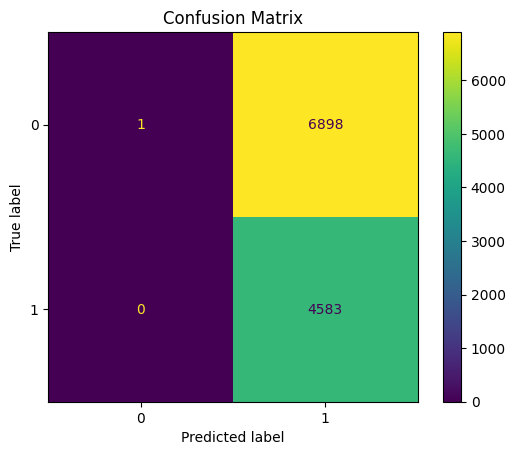

In [79]:
cm = confusion_matrix(y_test, xgb_tuned_pred)
print("\nConfusion Matrix for Tuned XGBoost:")
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

In [80]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_tuned.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 feature importances:")
print(importances.head(15))

Top 15 feature importances:
                feature  importance
0          total_visits    0.177448
1      number_inpatient    0.110162
6       diabetesmed_yes    0.102421
4      admitted_from_er    0.089541
2      number_diagnoses    0.082253
3      number_emergency    0.059163
13  emergency_admission    0.052525
7      time_in_hospital    0.049999
10      num_medications    0.049226
12       num_procedures    0.047495
11  treatment_intensity    0.047355
9       num_med_changed    0.045716
5     number_outpatient    0.044032
8            change_yes    0.042663


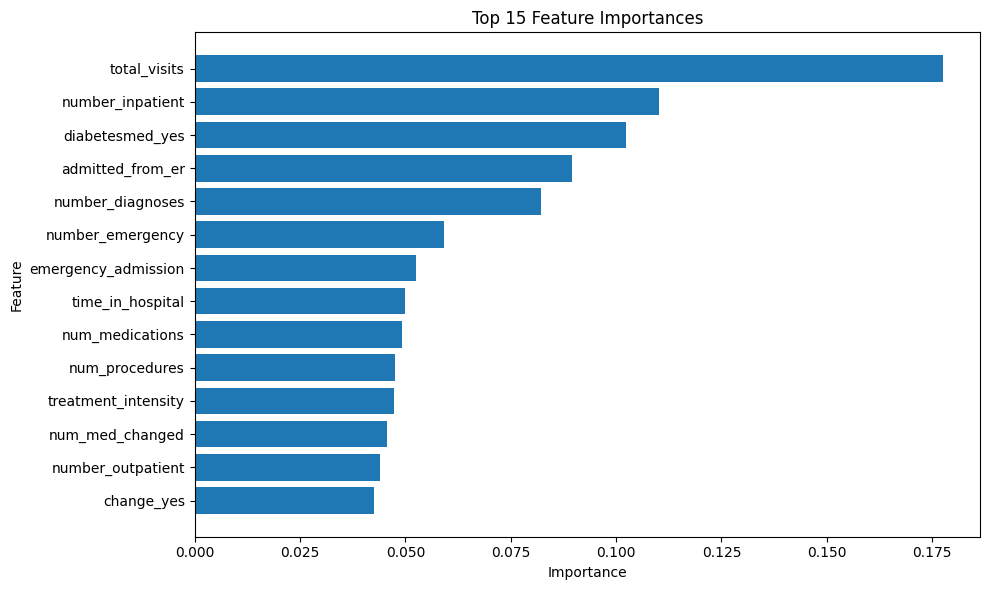

In [81]:
plt.figure(figsize=(10,6))
plt.barh(importances.head(15)["feature"][::-1], importances.head(15)["importance"][::-1])
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### **Key Insights from Modeling:**

- **Models chosen**: we previosuly shown that features are non linearly related. As such, we chose non linear models like Random Forest and XGBoost following SVM (rbf)

- **Metrics chosen:** Accuracy, F2 (prioritizes recall over precision), and AUC-ROC which are appropriate for healthcare where missing a readmission is more dangerous than a false alarm.

- **Bootstrap CI (500 iterations)** confirms all results are stable and reliable, not due to lucky test sampling.

- **Model progression:**

  | Model | Accuracy | F2 | AUC |
  |---|---|---|---|
  | Baseline | 0.6009 | 0.0 | 0.500 |
  | Random Forest | 0.5791 | 0.3637 | 0.5712 |
  | XGBoost | 0.5873 | 0.5703 | 0.6291 |
  | **XGBoost After Tuning** | **0.3992** | **0.7686** | **0.6217** |

- **Threshold tuning** found optimal threshold of 0.1 (vs default 0.5) improving F2 score from 57.03% to 76.86%.

- **Best model**: Comparing CI of our metrics, we find the tuned XGBoost the best having highest values for F2 prioritizing recall.

- **Confusion Matrix (Tuned XGBoost):**
  - **0 readmissions missed** out of 4,583
  - 6,898 false positives = extra monitoring -> clinically acceptable trade off

- **Top features confirmed EDA findings:**
  - **total_visits** (0.177) — engineered feature!
  - **number_inpatient** (0.110)
  - **diabetesmed_yes** (0.102)

## **Model Evaluation: Interpretation Beyond Scores:**

- **Why these metrics?** In a hospital readmission context, missing a patient who WILL be readmitted (False Negative) is far more dangerous than flagging a patient who won't (False Positive). This is why:
  - **F2** is used instead of **F1** since F2 weights recall twice as much as precision, reflecting the clinical cost imbalance (catching as many readmissions as possible)
  - **Accuracy** is used to be able to compare models with respect to the baseline model
  - **AUC-ROC** complements these by measuring overall discrimination regardless of threshold choice

- **What the numbers actually mean:**
  - Accuracy = 0.3992 -> our model correctly classify 39.92% of all patients (low)
  - F2 = 0.7686 -> strong overall performance weighted toward recall
  - AUC = 0.6217 -> model correctly ranks a random readmitted patient above a non readmitted patient 62.1% of the time somehow better than random chance (50%)

- **Bootstrap CI confirms reliability:**
  - XGBoost After Tuning F2 CI: (0.7625, 0.7748) -> extremely narrow, proving the F2 score is stable and not a lucky result
  - Wide CI would indicate unreliable results but most of ours are tight across all metrics

- **The threshold choice matters clinically:**
  - Default threshold (0.5) catches only 2732 of correct readmissions out of 4,583 -> unacceptable in healthcare
  - Tuned threshold (0.1) -> no only patients missed out of 4,583 total correct readmissions
  - The trade off: 6,898 false positives (extra monitoring) is a worthwhile cost to avoid missing real readmissions

- **Model progression shows clear improvement:**
  - Baseline → RF → XGBoost → Tuned XGBoost
  - Each step brought meaningful gains in F2 and AUC
  - XGBoost's tree based nature was essential for capturing the non linear & complex relationships between prior visit history, medications, and readmission

## **Interpretation & Decision Making (Practical Meaning):**

- **Real world implication:** Hospitals can use this model to flag high risk patients BEFORE discharge, allowing clinical teams to intervene early scheduling follow up appointments, adjusting medications, or extending the hospital stay when appropriate.

- **Who benefits most from this model?**
  - Patients with high **number_inpatient** and **total_visits**: model identifies these as highest risk and should trigger immediate care coordination
  - Patients with insulin dose changes (Up/Down): unstable diabetes management signals higher risk and closer post discharge monitoring
  - Patients admitted from emergency room: **admitted_from_er** ranked 2 in importance, meaning patients admitted through the ER tend to have more acute or unstable conditions which increases their likelihood of readmission.

- **Actionable insights for hospitals:**
  - **Flag patients with 2+ prior inpatient visits** for enhanced discharge planning
  - **Review insulin management** before discharge, any dose change should trigger a follow up call within 7 days
  - **Patients admitted from emergency room** show higher readmission risk coordinating more carefully
  - **Deploy model at discharge** with threshold=0.1: patients above this probability score receive a post discharge follow up call within 48 hours

- **Cost benefit consideration:**
  - 6,898 false positives = extra monitoring calls causes low cost intervention
  - 0 false negatives
  - The model's tradeoff strongly favors patient safety over operational efficiency


## **Uncertainty, Assumptions, Limitations & Bias:**

**Assumptions:**

- The first hospital encounter per patient is representative of their overall health profile and subsequent visits were dropped to prevent data leakage

- The binary target (readmitted yes/no) loses information about timing **<30 days and >30 days** so readmissions are treated equally despite having different clinical implications

- Historical patterns (1999-2008) will generalize to modern hospital settings

**Limitations:**

- **Outdated data:** Dataset spans 1999-2008 diabetes treatment has evolved significantly since then (new medications, protocols, technology). The model should be retrained periodically on recent data before any clinical deployment.

- **High missingness:** **weight** (96.9%), **max_glu_serum** (94.7%), **A1Cresult** (83.3%) were dropped, these are clinically important features that could have improved predictions

- **Single institution type:** Data comes from 130 US hospitals so results may not generalize to hospitals in other countries or healthcare systems

**Uncertainty:**

- All metrics come with 95% confidence intervals so true performance in deployment may fall anywhere within these ranges
- The optimal threshold (0.1) was selected on the validation set so its performance on truly unseen future data may vary
- Low feature correlations (all below 0.22) indicate readmission is inherently difficult to predict so there is irreducible uncertainty in the problem

**Bias:**

- **Demographic bias:** Over 70% of patients are Caucasian so the model may underperform for AfricanAmerican, Hispanic, and Asian patients who are underrepresented in training data
- **Survivorship bias:** Only patients who were hospitalized are included so the model cannot generalize to community or outpatient settings
- **Geographic bias:** Data is from US hospitals only and healthcare systems, insurance structures and treatment protocols differ globally
- **Temporal bias:** Older patients (65-80) dominate the dataset so predictions for younger diabetic patients may be less reliable

# **SVM:**

In [82]:
# training svm using rbf
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [83]:
# predictions
svm_pred = svm.predict(X_test)
svm_prob = svm.predict_proba(X_test)[:, 1]

# metrics
svm_acc = accuracy_score(y_test, svm_pred)
svm_f2 = fbeta_score(y_test, svm_pred, beta=2)
svm_auc = roc_auc_score(y_test, svm_prob)

# CI
svm_acc_ci, svm_f2_ci, svm_auc_ci = bootstrap_ci(y_test, svm_pred, svm_prob)

# save results
results.append({
    "Model": "SVM",
    "Accuracy": svm_acc,
    "Accuracy_CI": svm_acc_ci,
    "F2": svm_f2,
    "F2_CI": svm_f2_ci,
    "AUC": svm_auc,
    "AUC_CI": svm_auc_ci
})

results_df = pd.DataFrame(results)

print("Model Comparison:")
for i in range(len(results_df)):
    print("\nModel:", results_df.loc[i, "Model"])

    acc_ci = results_df.loc[i, "Accuracy_CI"]
    f2_ci = results_df.loc[i, "F2_CI"]
    auc_ci = results_df.loc[i, "AUC_CI"]

    print(
        "Accuracy:", round(results_df.loc[i, "Accuracy"], 4),
        "| 95% CI:", tuple(np.round(acc_ci, 4)) if isinstance(acc_ci, (tuple, list, np.ndarray)) else acc_ci
    )
    print(
        "F2:", round(results_df.loc[i, "F2"], 4),
        "| 95% CI:", tuple(np.round(f2_ci, 4)) if isinstance(f2_ci, (tuple, list, np.ndarray)) else f2_ci
    )
    print(
        "AUC:", round(results_df.loc[i, "AUC"], 4),
        "| 95% CI:", tuple(np.round(auc_ci, 4)) if isinstance(auc_ci, (tuple, list, np.ndarray)) else auc_ci
    )

Model Comparison:

Model: Baseline (Most Frequent)
Accuracy: 0.6009 | 95% CI: (np.float64(0.5924), np.float64(0.609))
F2: 0.0 | 95% CI: (np.float64(0.0), np.float64(0.0))
AUC: 0.5 | 95% CI: (np.float64(0.5), np.float64(0.5))

Model: Random Forest
Accuracy: 0.5791 | 95% CI: (np.float64(0.5702), np.float64(0.5878))
F2: 0.3637 | 95% CI: (np.float64(0.351), np.float64(0.3769))
AUC: 0.5712 | 95% CI: (np.float64(0.5611), np.float64(0.5816))

Model: XGBoost
Accuracy: 0.5873 | 95% CI: (np.float64(0.5769), np.float64(0.5962))
F2: 0.5703 | 95% CI: (np.float64(0.5573), np.float64(0.5825))
AUC: 0.6291 | 95% CI: (np.float64(0.6181), np.float64(0.6394))

Model: XGBoost After Tuning (threshold=0.10)
Accuracy: 0.3992 | 95% CI: (np.float64(0.3911), np.float64(0.4076))
F2: 0.7686 | 95% CI: (np.float64(0.7625), np.float64(0.7748))
AUC: 0.6217 | 95% CI: (np.float64(0.6102), np.float64(0.6318))

Model: SVM
Accuracy: 0.566 | 95% CI: (np.float64(0.5562), np.float64(0.576))
F2: 0.5437 | 95% CI: (np.float64(0.

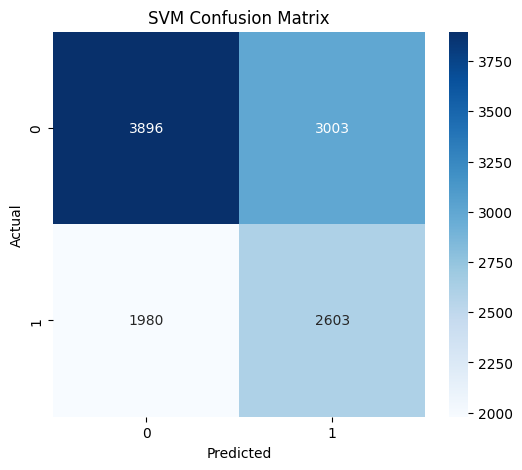

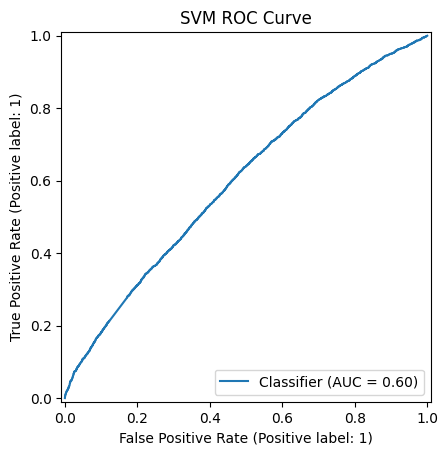

In [84]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

RocCurveDisplay.from_predictions(y_test, svm_prob)
plt.title("SVM ROC Curve")
plt.show()

### **To extend our research:**
We included the SVM model (it takes around 15-20 minutes running)

### **Interpretation of performance:**

- The SVM model achieved moderate performance (F2 = 0.54 & AUC = 0.59), indicating a limited ability to distinguish between readmitted and non readmitted patients

- While it captures some non linear patterns, it produces a high number of false negatives which is not desired in the healthcare domain

- Compared to SVM, the tuned XGBoost model significantly improves F2 and the overall predictive performance, making it a more preferable model for this task